# Experimento 6 — Defecto Super-Gaussiano en la Arista Tapa/Pared Lateral

**Motivación:** En los experimentos anteriores la pieza era un cilindro simple (una sola superficie).
En piezas reales de forja existen **geometrías compuestas**: una tapa plana (base del cilindro)
y una pared lateral cilíndrica se unen en una **arista**. Los defectos críticos suelen aparecer
justo en esa transición, por las concentraciones de tensiones de forja.

**Pieza sintética:**
- **Tapa** (base plana): $Z = Z_{tapa}$ = constante, para $X > X_{arista}$
- **Pared lateral** (cilíndrica): $Z = \sqrt{R^2 - X^2}$, para $X < X_{arista}$
- **Arista** (chanfrán): transición suave entre ambas superficies

**Defecto sintético:** Super-gaussiana ($n=2$) centrada en la arista, **orientada a 45°**:
$$f(x,y) = A\exp\!\left(-\left(\frac{u^2}{2\sigma_u^2}+\frac{v^2}{2\sigma_v^2}\right)^n\right),\quad u = (x-x_0)\cos\theta + (y-y_0)\sin\theta$$

**Objetivo:**
1. Reconocer automáticamente la pieza fantasma: identificar tapa vs pared por análisis de curvatura (filtro SG)
2. Estimar los parámetros geométricos ($R$, $Z_{tapa}$, $X_{arista}$) sin CAD
3. Reconstruir la superficie nominal y detectar el defecto en la arista

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.optimize import least_squares, minimize_scalar
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import pandas as pd
import time as _time

## 1. Geometría de la pieza fantasma: tapa + pared lateral + arista

In [3]:
# ── Parámetros físicos ────────────────────────────────────────────────────────
# Tras la rotación 45° del sensor:
#   - TAPA (cara plana circular): Z = Z_TAPA para r = sqrt(X²+Y²) < R
#   - PARED lateral (rodea TODA la tapa): Z = Z_TAPA − (r − R) para r ≥ R
#   - ARISTA: círculo r = R en la imagen (no una línea vertical)
R          = 35.0   # mm — radio de la tapa y de la arista
Z_TAPA     = 50.0   # mm — altura de la cara plana
WALL_DEPTH = 12.0   # mm — profundidad de pared visible (sensor 45°: 1mm profundidad/mm imagen)
FOV_X      = 120.0  # mm
FOV_Y      = 100.0  # mm
N_ROWS     = 512
N_COLS     = 614

dx = FOV_X / N_COLS
dy = FOV_Y / N_ROWS

x_vec = np.linspace(-FOV_X/2, FOV_X/2, N_COLS)
y_vec = np.linspace(-FOV_Y/2, FOV_Y/2, N_ROWS)
X_img, Y_img = np.meshgrid(x_vec, y_vec)

# ── Radio en imagen ────────────────────────────────────────────────────────────
r_img = np.sqrt(X_img**2 + Y_img**2)

# ── Máscaras de región ─────────────────────────────────────────────────────────
mask_tapa  = r_img < R
mask_pared = (r_img >= R) & (r_img < R + WALL_DEPTH)
mask_valid = mask_tapa | mask_pared

# ── Superficie nominal compuesta ───────────────────────────────────────────────
Z_nominal = np.where(mask_tapa,  Z_TAPA,
             np.where(mask_pared, Z_TAPA - (r_img - R), 0.0))

# ── Geometría de apoyo para visualización ─────────────────────────────────────
row_mid      = N_ROWS // 2
theta_circle = np.linspace(0, 2 * np.pi, 360)

print(f'Resolución: dx={dx:.4f} mm/px, dy={dy:.4f} mm/px')
print(f'Radio arista R={R} mm  |  Profundidad pared visible={WALL_DEPTH} mm')
print(f'Z_TAPA = {Z_TAPA:.2f} mm  |  Z_pared_min = {Z_TAPA - WALL_DEPTH:.2f} mm')
print(f'Tapa:  {mask_tapa.sum():6d} px | Pared: {mask_pared.sum():6d} px | Total: {mask_valid.sum():6d} px')
print(f'Pared completamente visible: R+WALL_DEPTH={R+WALL_DEPTH} mm < FOV_Y/2={FOV_Y/2} mm → OK')

Resolución: dx=0.1954 mm/px, dy=0.1953 mm/px
Radio arista R=35.0 mm  |  Profundidad pared visible=12.0 mm
Z_TAPA = 50.00 mm  |  Z_pared_min = 38.00 mm
Tapa:  100476 px | Pared:  80708 px | Total: 181184 px
Pared completamente visible: R+WALL_DEPTH=47.0 mm < FOV_Y/2=50.0 mm → OK


## 2. Visualización de la pieza compuesta

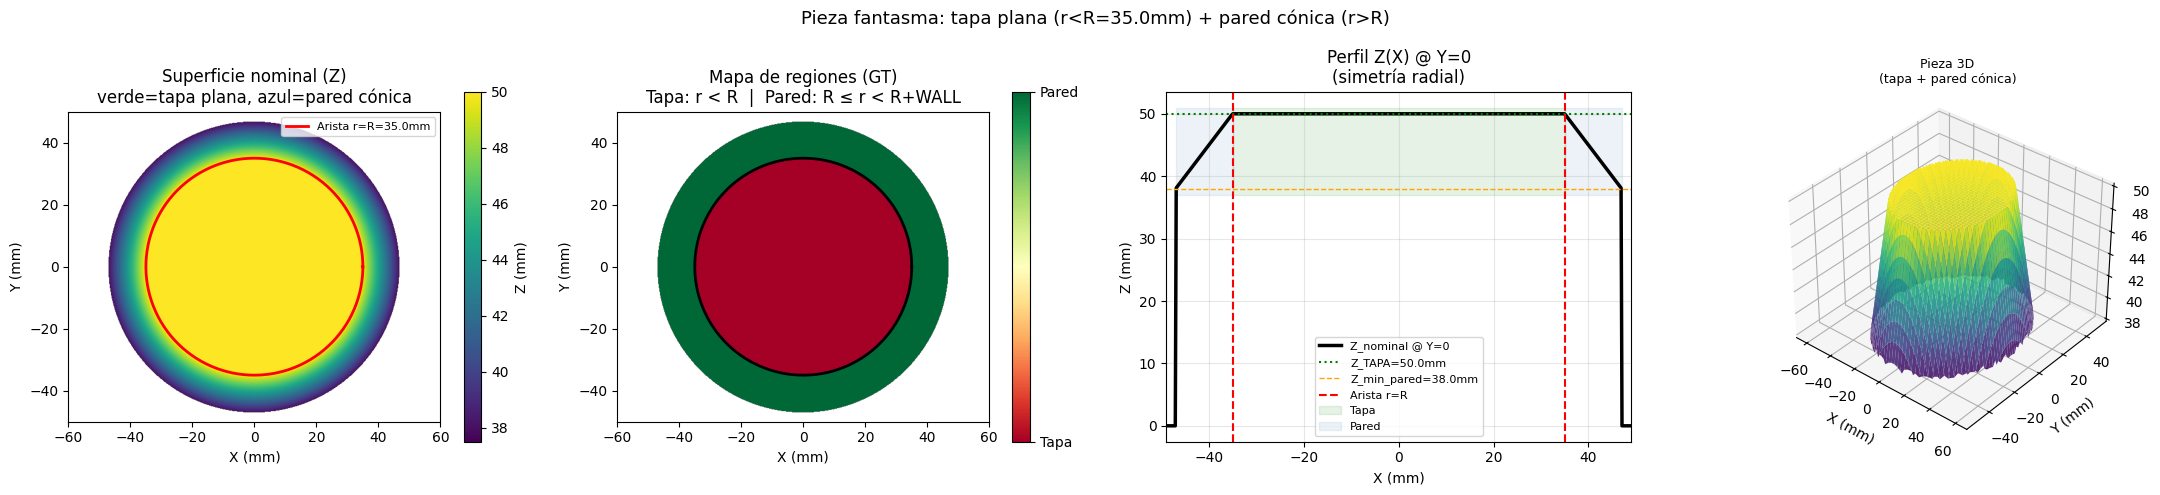

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

Znom_show = np.where(mask_valid, Z_nominal, np.nan)

# Mapa 2D de la superficie nominal
im0 = axes[0].imshow(Znom_show, origin='lower', aspect='auto',
                     extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='viridis', vmin=Z_TAPA - WALL_DEPTH - 0.5)
plt.colorbar(im0, ax=axes[0], label='Z (mm)')
axes[0].plot(R * np.cos(theta_circle), R * np.sin(theta_circle),
             'r-', lw=2, label=f'Arista r=R={R}mm')
axes[0].set_title('Superficie nominal (Z)\nverde=tapa plana, azul=pared cónica')
axes[0].set_xlabel('X (mm)'); axes[0].set_ylabel('Y (mm)')
axes[0].legend(fontsize=8)
axes[0].set_aspect('equal')

# Mapa de regiones
region_map = np.full_like(Z_nominal, np.nan)
region_map[mask_pared] = 1.0
region_map[mask_tapa]  = 0.0
im1 = axes[1].imshow(region_map, origin='lower', aspect='auto',
                     extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im1, ax=axes[1], ticks=[0, 1]).set_ticklabels(['Tapa', 'Pared'])
axes[1].plot(R * np.cos(theta_circle), R * np.sin(theta_circle), 'k-', lw=2)
axes[1].set_title('Mapa de regiones (GT)\nTapa: r < R  |  Pared: R ≤ r < R+WALL')
axes[1].set_xlabel('X (mm)'); axes[1].set_ylabel('Y (mm)')
axes[1].set_aspect('equal')

# Perfil radial Z(X) @ Y=0
axes[2].plot(x_vec, Z_nominal[row_mid, :], 'k-', lw=2.5, label='Z_nominal @ Y=0')
axes[2].axhline(Z_TAPA, color='green', lw=1.5, ls=':', label=f'Z_TAPA={Z_TAPA:.1f}mm')
axes[2].axhline(Z_TAPA - WALL_DEPTH, color='orange', lw=1, ls='--',
                label=f'Z_min_pared={Z_TAPA-WALL_DEPTH:.1f}mm')
axes[2].axvline(-R, color='r', lw=1.5, ls='--', label='Arista r=R')
axes[2].axvline( R, color='r', lw=1.5, ls='--')
axes[2].fill_betweenx([Z_TAPA - WALL_DEPTH - 1, Z_TAPA + 1], -R, R,
                       alpha=0.1, color='green', label='Tapa')
axes[2].fill_betweenx([Z_TAPA - WALL_DEPTH - 1, Z_TAPA + 1], -(R+WALL_DEPTH), -R,
                       alpha=0.1, color='steelblue')
axes[2].fill_betweenx([Z_TAPA - WALL_DEPTH - 1, Z_TAPA + 1], R, R+WALL_DEPTH,
                       alpha=0.1, color='steelblue', label='Pared')
axes[2].set_xlabel('X (mm)'); axes[2].set_ylabel('Z (mm)')
axes[2].set_title('Perfil Z(X) @ Y=0\n(simetría radial)')
axes[2].legend(fontsize=8, loc='lower center'); axes[2].grid(alpha=0.3)
axes[2].set_xlim(-(R + WALL_DEPTH + 2), R + WALL_DEPTH + 2)

# Vista 3D
st3d = 3
Xv = X_img[::st3d, ::st3d]; Yv = Y_img[::st3d, ::st3d]
Zv = np.where(mask_valid[::st3d, ::st3d], Z_nominal[::st3d, ::st3d], np.nan)
ax3d = fig.add_subplot(1, 4, 4, projection='3d', position=axes[3].get_position())
axes[3].set_visible(False)
ax3d.plot_surface(Xv, Yv, Zv, cmap='viridis', alpha=0.9,
                  rcount=60, ccount=60, linewidth=0)
ax3d.set_xlabel('X (mm)'); ax3d.set_ylabel('Y (mm)'); ax3d.set_zlabel('Z (mm)')
ax3d.set_title('Pieza 3D\n(tapa + pared cónica)', fontsize=9)
ax3d.view_init(elev=35, azim=-50)

plt.suptitle(f'Pieza fantasma: tapa plana (r<R={R}mm) + pared cónica (r>R)', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Filtro SG: definición de funciones

In [5]:
def sg2d_jacobian_projection_cv2(Z, window_size=11):
    assert window_size % 2 == 1
    hw = window_size // 2
    y_idx, x_idx = np.mgrid[-hw:hw+1, -hw:hw+1]
    regressors = np.stack([
        x_idx**2, y_idx**2, x_idx * y_idx,
        x_idx, y_idx, np.ones_like(x_idx)
    ], axis=-1)
    A_mat = regressors.reshape(-1, 6)
    pseudo = np.linalg.inv(A_mat.T @ A_mat) @ A_mat.T
    kernels = pseudo.reshape(6, window_size, window_size)
    return np.stack(
        [cv2.filter2D(Z.astype(np.float64), -1, k,
                      borderType=cv2.BORDER_REFLECT) for k in kernels],
        axis=-1
    )

def coeffs_to_physical(coeffs_px, dx, dy):
    a_ph = coeffs_px[..., 0] / dx**2
    b_ph = coeffs_px[..., 1] / dy**2
    c_ph = coeffs_px[..., 2] / (dx * dy)
    d_ph = coeffs_px[..., 3] / dx
    e_ph = coeffs_px[..., 4] / dy
    f0   = coeffs_px[..., 5]
    return np.stack([a_ph, b_ph, c_ph, d_ph, e_ph, f0], axis=-1)

print('Funciones SG definidas.')

Funciones SG definidas.


## 4. Análisis de curvatura: identificación de topología de la pieza

El filtro SG ajusta localmente un paraboloide: $Z \approx a x^2 + b y^2 + \ldots$

Las **curvaturas principales** son:
- $\kappa_1 = 2a_{ph}$ (curvatura en X)
- $\kappa_2 = 2b_{ph}$ (curvatura en Y)

Para la **pared cilíndrica** (eje en Y): $\kappa_1 = -R^2/Z^3 \approx -1/R \neq 0$, $\kappa_2 \approx 0$

Para la **tapa plana**: $\kappa_1 \approx 0$, $\kappa_2 \approx 0$

→ El signo y magnitud de $\kappa_1$ distingue perfectamente las dos regiones.

WIN_TOPO = 10.0 mm = 51 px
WALL_SLOPE = 1.0  |  GRAD_THRESH = -0.300
dZ/dr mediana tapa:  -0.0000 mm/mm
dZ/dr mediana pared: -1.3133 mm/mm
H mediana tapa:  -0.00000 mm⁻¹
H mediana pared: -0.10001 mm⁻¹


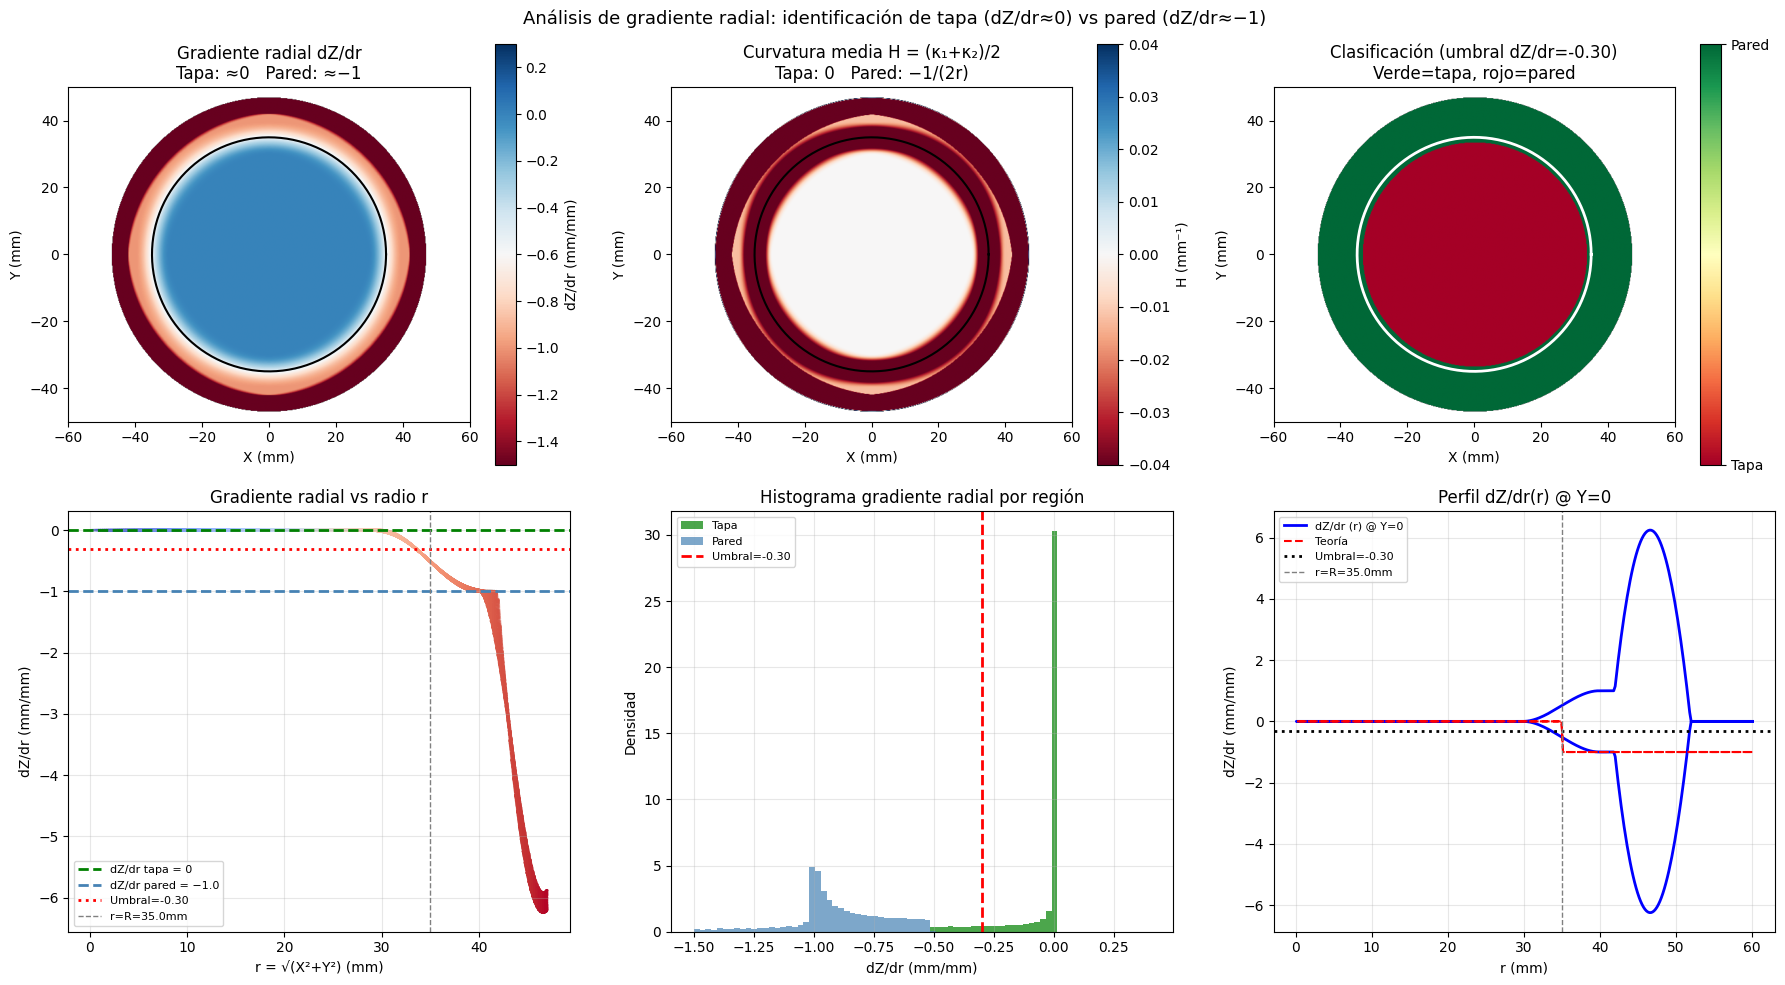

In [6]:
# ── Filtro SG para identificación de la topología ────────────────────────────
# Para esta geometría (tapa plana + pared cónica) el CRITERIO óptimo es el
# GRADIENTE RADIAL dZ/dr:
#   Tapa plana:          dZ/dr = 0
#   Pared cónica (45°):  dZ/dr = −WALL_SLOPE = −1
#
# La curvatura H = −1/(2r) en la pared es pequeña (≈ −0.013 mm⁻¹) y la arista
# ABRUPTA crea artefactos de curvatura mucho mayores en el filtro SG → menos
# fiable que el gradiente para ventanas grandes.
WIN_TOPO_MM = 10.0   # mm — ventana para estimación de gradiente/curvatura
WIN_TOPO_PX = int(round(WIN_TOPO_MM / min(dx, dy))) | 1

coeffs_nom_px = sg2d_jacobian_projection_cv2(Z_nominal, window_size=WIN_TOPO_PX)
coeffs_nom_ph = coeffs_to_physical(coeffs_nom_px, dx, dy)

# Coeficientes de primer orden (gradientes locales en mm/mm)
d_ph = coeffs_nom_ph[..., 3]   # dZ/dX
e_ph = coeffs_nom_ph[..., 4]   # dZ/dY

# Gradiente radial: dZ/dr = (X·dZ/dX + Y·dZ/dY) / r
# Negativo en la pared (Z disminuye cuando r aumenta)
r_safe  = np.maximum(r_img, 1e-6)
dZdr    = (X_img * d_ph + Y_img * e_ph) / r_safe

# Curvatura media (para referencia)
kappa1_nom = 2 * coeffs_nom_ph[..., 0]
kappa2_nom = 2 * coeffs_nom_ph[..., 1]
H_nom      = (kappa1_nom + kappa2_nom) / 2.0

# ── Umbrales de clasificación ──────────────────────────────────────────────────
WALL_SLOPE  = 1.0         # mm/mm — pendiente de la pared (sensor a 45°)
GRAD_THRESH = -0.3 * WALL_SLOPE   # umbral: mitad de la pendiente esperada

# Para curvatura (referencia)
H_theory_wall = -1.0 / (2 * R)
H_thresh      = H_theory_wall / 2.0

print(f'WIN_TOPO = {WIN_TOPO_MM} mm = {WIN_TOPO_PX} px')
print(f'WALL_SLOPE = {WALL_SLOPE}  |  GRAD_THRESH = {GRAD_THRESH:.3f}')
print(f'dZ/dr mediana tapa:  {np.median(dZdr[mask_tapa]):.4f} mm/mm')
print(f'dZ/dr mediana pared: {np.median(dZdr[mask_pared]):.4f} mm/mm')
print(f'H mediana tapa:  {np.median(H_nom[mask_tapa]):.5f} mm⁻¹')
print(f'H mediana pared: {np.median(H_nom[mask_pared]):.5f} mm⁻¹')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Mapa dZ/dr
im0 = axes[0, 0].imshow(np.where(mask_valid, dZdr, np.nan),
                         origin='lower', aspect='auto',
                         extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                         cmap='RdBu', vmin=-1.5, vmax=0.3)
plt.colorbar(im0, ax=axes[0, 0], label='dZ/dr (mm/mm)')
axes[0, 0].plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'k-', lw=1.5)
axes[0, 0].set_title('Gradiente radial dZ/dr\nTapa: ≈0   Pared: ≈−1')
axes[0, 0].set_xlabel('X (mm)'); axes[0, 0].set_ylabel('Y (mm)')
axes[0, 0].set_aspect('equal')

# Mapa H
kv = 0.04
im1 = axes[0, 1].imshow(np.where(mask_valid, H_nom, np.nan),
                         origin='lower', aspect='auto',
                         extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                         cmap='RdBu', vmin=-kv, vmax=kv)
plt.colorbar(im1, ax=axes[0, 1], label='H (mm⁻¹)')
axes[0, 1].plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'k-', lw=1.5)
axes[0, 1].set_title('Curvatura media H = (κ₁+κ₂)/2\nTapa: 0   Pared: −1/(2r)')
axes[0, 1].set_xlabel('X (mm)'); axes[0, 1].set_ylabel('Y (mm)')
axes[0, 1].set_aspect('equal')

# Clasificación binaria
clf_map = np.where(mask_valid, (dZdr < GRAD_THRESH).astype(float), np.nan)
im2 = axes[0, 2].imshow(clf_map, origin='lower', aspect='auto',
                          extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                          cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im2, ax=axes[0, 2], ticks=[0, 1]).set_ticklabels(['Tapa', 'Pared'])
axes[0, 2].plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'w-', lw=2)
axes[0, 2].set_title(f'Clasificación (umbral dZ/dr={GRAD_THRESH:.2f})\nVerde=tapa, rojo=pared')
axes[0, 2].set_xlabel('X (mm)'); axes[0, 2].set_ylabel('Y (mm)')
axes[0, 2].set_aspect('equal')

# Perfil dZ/dr(r) scatter
r_flat   = r_img[mask_valid].ravel()
dZdr_flat = dZdr[mask_valid].ravel()
ord_r    = np.argsort(r_flat)
axes[1, 0].scatter(r_flat[ord_r][::5], dZdr_flat[ord_r][::5],
                   c=r_flat[ord_r][::5], cmap='coolwarm', s=1, alpha=0.3)
axes[1, 0].axhline(0,           color='green', lw=2, ls='--', label='dZ/dr tapa = 0')
axes[1, 0].axhline(-WALL_SLOPE, color='steelblue', lw=2, ls='--',
                    label=f'dZ/dr pared = −{WALL_SLOPE}')
axes[1, 0].axhline(GRAD_THRESH, color='r', lw=2, ls=':', label=f'Umbral={GRAD_THRESH:.2f}')
axes[1, 0].axvline(R, color='gray', lw=1, ls='--', label=f'r=R={R}mm')
axes[1, 0].set_xlabel('r = √(X²+Y²) (mm)'); axes[1, 0].set_ylabel('dZ/dr (mm/mm)')
axes[1, 0].set_title('Gradiente radial vs radio r')
axes[1, 0].legend(fontsize=8); axes[1, 0].grid(alpha=0.3)

# Histograma dZ/dr
bins = np.linspace(-1.5, 0.4, 80)
axes[1, 1].hist(dZdr[mask_tapa].ravel(),  bins=bins, color='green',     alpha=0.7,
                label=f'Tapa', density=True)
axes[1, 1].hist(dZdr[mask_pared].ravel(), bins=bins, color='steelblue', alpha=0.7,
                label=f'Pared', density=True)
axes[1, 1].axvline(GRAD_THRESH, color='r', lw=2, ls='--', label=f'Umbral={GRAD_THRESH:.2f}')
axes[1, 1].set_xlabel('dZ/dr (mm/mm)'); axes[1, 1].set_ylabel('Densidad')
axes[1, 1].set_title('Histograma gradiente radial por región')
axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=0.3)

# Perfil dZ/dr @ Y=0
r_line = np.abs(x_vec)
dZdr_theory = np.where(r_line >= R, -WALL_SLOPE, 0.0)
dZdr_line   = np.where(x_vec >= 0, dZdr[row_mid, :],
                        -dZdr[row_mid, :])  # flip sign for negative X (dZ/dr ← positive X direction)
axes[1, 2].plot(r_line, dZdr_line, 'b-', lw=2, label='dZ/dr (r) @ Y=0')
axes[1, 2].plot(r_line, dZdr_theory, 'r--', lw=1.5, label='Teoría')
axes[1, 2].axhline(GRAD_THRESH, color='k', lw=2, ls=':', label=f'Umbral={GRAD_THRESH:.2f}')
axes[1, 2].axvline(R, color='gray', lw=1, ls='--', label=f'r=R={R}mm')
axes[1, 2].set_xlabel('r (mm)'); axes[1, 2].set_ylabel('dZ/dr (mm/mm)')
axes[1, 2].set_title('Perfil dZ/dr(r) @ Y=0')
axes[1, 2].legend(fontsize=8); axes[1, 2].grid(alpha=0.3)

plt.suptitle('Análisis de gradiente radial: identificación de tapa (dZ/dr≈0) vs pared (dZ/dr≈−1)',
             fontsize=13)
plt.tight_layout()
plt.show()

## 5. Segmentación automática: tapa vs pared

**Criterio:** $\kappa_1 < \kappa_{umbral}$ (negativo y suficientemente grande en valor absoluto) → pared cilíndrica.  
**Umbral:** $\kappa_{umbral} = -1/(2R)$ (mitad de la curvatura esperada en el centro).

La región de chanfrán (transición) se trata como zona de exclusión para el ajuste.

Umbral dZ/dr: -0.300 mm/mm
Tapa segmentada:    92028 px  |  GT: 100476 px
Pared segmentada:   89156 px  |  GT:  80708 px
R_est = 34.00 ± 0.29 mm  (GT R=35.00 mm, err=-1.00 mm)
Precisión segmentación (excluyendo chanfrán ±4.9mm): 100.00%


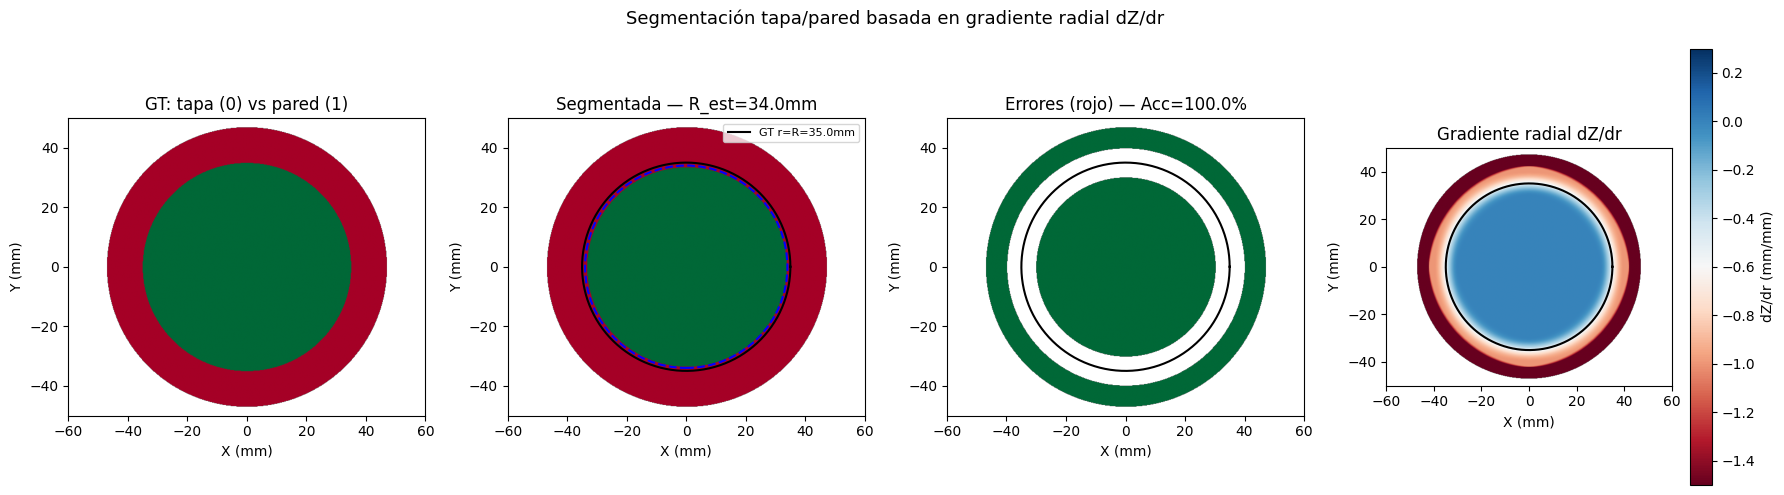

In [7]:
# ── Segmentación: tapa vs. pared ──────────────────────────────────────────────
# Criterio: gradiente radial dZ/dr < GRAD_THRESH  →  pared (pendiente de la pared ≈ −1)
#           dZ/dr ≥ GRAD_THRESH                   →  tapa  (plana,  pendiente ≈ 0)
raw_pared = (dZdr < GRAD_THRESH) & mask_valid
raw_tapa  = (~raw_pared) & mask_valid

# Limpieza morfológica
ker_px = max(3, int(round(2.0 / min(dx, dy))) | 1)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ker_px, ker_px))
seg_pared_raw = cv2.morphologyEx(raw_pared.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
seg_tapa_raw  = cv2.morphologyEx(raw_tapa.astype(np.uint8),  cv2.MORPH_CLOSE, kernel)

seg_pared = seg_pared_raw.astype(bool) & mask_valid
seg_tapa  = seg_tapa_raw.astype(bool)  & mask_valid & ~seg_pared

# ── Estimación del radio R desde la máscara seg_tapa ─────────────────────────
# La frontera externa de seg_tapa coincide con la arista circular r = R
border_tapa = cv2.morphologyEx(seg_tapa.astype(np.uint8), cv2.MORPH_DILATE, kernel) \
              & ~seg_tapa
border_pts  = np.column_stack(np.where(border_tapa))  # (row, col)
if len(border_pts):
    r_border = np.sqrt(
        (x_vec[border_pts[:, 1]] ** 2) +
        (y_vec[border_pts[:, 0]] ** 2))
    R_est     = float(np.median(r_border))
    R_est_std = float(np.std(r_border))
else:
    R_est = R_est_std = float('nan')

# ── Precisión de la segmentación ──────────────────────────────────────────────
# Excluir banda angosta alrededor de la arista (= 1 ventana de identificación)
MARGIN_PX   = int(WIN_TOPO_PX // 2)
dist_from_R = np.abs(r_img - R)
far_mask    = (dist_from_R > MARGIN_PX * min(dx, dy)) & mask_valid

correct = ((seg_tapa == mask_tapa) | (seg_pared == mask_pared)) & far_mask
acc = float(correct.sum()) / float(far_mask.sum()) * 100

print(f'Umbral dZ/dr: {GRAD_THRESH:.3f} mm/mm')
print(f'Tapa segmentada:   {seg_tapa.sum():6d} px  |  GT: {mask_tapa.sum():6d} px')
print(f'Pared segmentada:  {seg_pared.sum():6d} px  |  GT: {mask_pared.sum():6d} px')
print(f'R_est = {R_est:.2f} ± {R_est_std:.2f} mm  (GT R={R:.2f} mm, '
      f'err={R_est-R:+.2f} mm)')
print(f'Precisión segmentación (excluyendo chanfrán ±{MARGIN_PX*min(dx,dy):.1f}mm): {acc:.2f}%')

# Visualización
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# GT mask
gt_map = np.where(mask_valid, mask_pared.astype(float), np.nan)
im0 = axes[0].imshow(gt_map, origin='lower', aspect='auto',
                      extent=[-FOV_X/2,FOV_X/2,-FOV_Y/2,FOV_Y/2],
                      cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0].set_title('GT: tapa (0) vs pared (1)'); axes[0].set_aspect('equal')

# Segmentación
seg_map = np.where(mask_valid, seg_pared.astype(float), np.nan)
im1 = axes[1].imshow(seg_map, origin='lower', aspect='auto',
                      extent=[-FOV_X/2,FOV_X/2,-FOV_Y/2,FOV_Y/2],
                      cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'k-', lw=1.5, label=f'GT r=R={R}mm')
c_est = plt.Circle((0,0), R_est, color='b', fill=False, lw=1.5, ls='--')
axes[1].add_patch(c_est)
axes[1].legend(fontsize=8); axes[1].set_title(f'Segmentada — R_est={R_est:.1f}mm')
axes[1].set_aspect('equal')

# Error mapa
err_map = np.where(far_mask, np.where(correct, 0.0, 1.0), np.nan)
im2 = axes[2].imshow(err_map, origin='lower', aspect='auto',
                      extent=[-FOV_X/2,FOV_X/2,-FOV_Y/2,FOV_Y/2],
                      cmap='RdYlGn_r', vmin=0, vmax=1)
axes[2].plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'k-', lw=1.5)
axes[2].set_title(f'Errores (rojo) — Acc={acc:.1f}%'); axes[2].set_aspect('equal')

# dZ/dr mapa para referencia
im3 = axes[3].imshow(np.where(mask_valid, dZdr, np.nan), origin='lower', aspect='auto',
                      extent=[-FOV_X/2,FOV_X/2,-FOV_Y/2,FOV_Y/2],
                      cmap='RdBu', vmin=-1.5, vmax=0.3)
plt.colorbar(im3, ax=axes[3], label='dZ/dr (mm/mm)')
axes[3].plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'k-', lw=1.5)
axes[3].set_title('Gradiente radial dZ/dr'); axes[3].set_aspect('equal')

for ax in axes:
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')

plt.suptitle('Segmentación tapa/pared basada en gradiente radial dZ/dr', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Estimación de la pieza nominal sin CAD

Con las regiones segmentadas:
1. **Pared** → ajustar $R_{est}$ con mínimos cuadrados
2. **Tapa** → estimar $Z_{tapa,est}$ como mediana de $Z$ medida en esa región
3. **Arista** → interpolar entre las dos superficies (mismo modelo de chanfrán)

Para robustecer la estimación, se usa un **margen de seguridad** de $\pm$ varios mm alrededor de la arista detectada.

In [8]:
# ── Margen de seguridad alrededor de la arista estimada ───────────────────────
MARGIN_EST_MM  = 4.0  # mm — excluir esta franja radial alrededor de r = R_est

mask_tapa_safe  = seg_tapa  & (r_img < R_est - MARGIN_EST_MM) & mask_valid
mask_pared_safe = seg_pared & (r_img > R_est + MARGIN_EST_MM) & mask_valid

print(f'Margen ±{MARGIN_EST_MM} mm alrededor de R_est={R_est:.1f} mm')
print(f'Pixels tapa  para ajuste: {mask_tapa_safe.sum()}')
print(f'Pixels pared para ajuste: {mask_pared_safe.sum()}')

# ── Estimación de Z_TAPA ─────────────────────────────────────────────────────
z_tapa_vals = Z_nominal[mask_tapa_safe].ravel()
Z_tapa_est  = float(np.median(z_tapa_vals))

# ── Estimación de R mediante el modelo lineal de la pared ─────────────────────
# Z_obs = Z_TAPA − (r − R)  →  Z_obs + r = Z_TAPA + R = cte
# Por tanto: median(Z_obs + r) = Z_TAPA + R → R = cte − Z_TAPA
z_pared_vals = Z_nominal[mask_pared_safe].ravel()
r_pared_vals = r_img[mask_pared_safe].ravel()
ZR_const     = float(np.median(z_pared_vals + r_pared_vals))   # Z_TAPA + R
R_est_fit    = ZR_const - Z_tapa_est                            # R estimada

# ── Reconstrucción de la superficie nominal estimada ──────────────────────────
Z_nominal_est = np.where(mask_tapa,  Z_tapa_est,
                 np.where(mask_pared, Z_tapa_est - (r_img - R_est_fit), 0.0))
Z_nominal_est = np.where(mask_valid, Z_nominal_est, 0.0)

err_nom = Z_nominal_est - Z_nominal

print(f'\nZ_tapa_est = {Z_tapa_est:.6f} mm  (GT={Z_TAPA:.4f} mm,  err={Z_tapa_est-Z_TAPA:+.6f} mm)')
print(f'(Z_TAPA+R)_est = {ZR_const:.6f} mm  (GT={Z_TAPA+R:.4f} mm)')
print(f'R_est_fit  = {R_est_fit:.6f} mm  (GT={R:.4f} mm,      err={R_est_fit-R:+.6f} mm)')
print(f'RMS error nominal (tapa):  {np.sqrt(np.mean(err_nom[mask_tapa]**2))*1000:.2f} µm')
print(f'RMS error nominal (pared): {np.sqrt(np.mean(err_nom[mask_pared]**2))*1000:.2f} µm')

Margen ±4.0 mm alrededor de R_est=34.0 mm
Pixels tapa  para ajuste: 73800
Pixels pared para ajuste: 62756

Z_tapa_est = 50.000000 mm  (GT=50.0000 mm,  err=+0.000000 mm)
(Z_TAPA+R)_est = 85.000000 mm  (GT=85.0000 mm)
R_est_fit  = 35.000000 mm  (GT=35.0000 mm,      err=+0.000000 mm)
RMS error nominal (tapa):  0.00 µm
RMS error nominal (pared): 0.00 µm


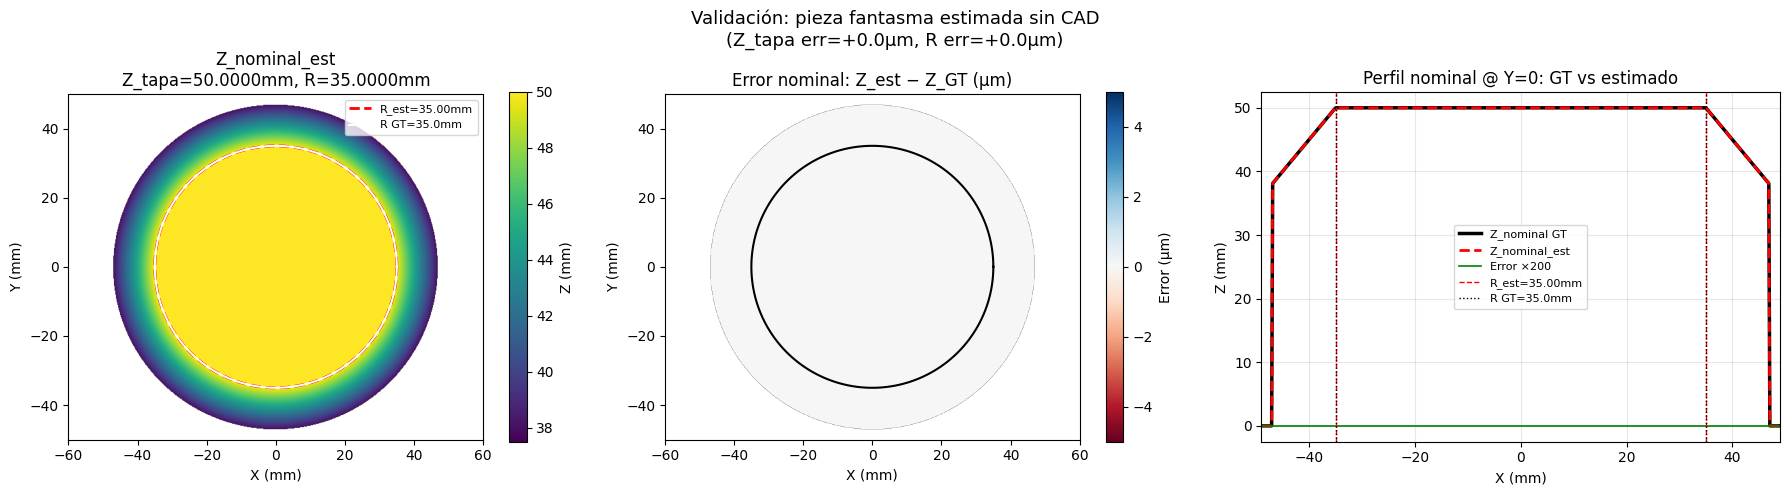

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Zest_show = np.where(mask_valid, Z_nominal_est, np.nan)
im0 = axes[0].imshow(Zest_show, origin='lower', aspect='auto',
                     extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='viridis', vmin=Z_TAPA - WALL_DEPTH - 0.5)
plt.colorbar(im0, ax=axes[0], label='Z (mm)')
axes[0].plot(R_est_fit * np.cos(theta_circle), R_est_fit * np.sin(theta_circle),
             'r--', lw=2, label=f'R_est={R_est_fit:.2f}mm')
axes[0].plot(R * np.cos(theta_circle), R * np.sin(theta_circle),
             'w-', lw=1.5, label=f'R GT={R}mm')
axes[0].set_title(f'Z_nominal_est\nZ_tapa={Z_tapa_est:.4f}mm, R={R_est_fit:.4f}mm')
axes[0].set_xlabel('X (mm)'); axes[0].set_ylabel('Y (mm)')
axes[0].legend(fontsize=8); axes[0].set_aspect('equal')

vmax_err = max(np.abs(err_nom[mask_valid]).max(), 0.005)
err_show = np.where(mask_valid, err_nom * 1000, np.nan)
im1 = axes[1].imshow(err_show, origin='lower', aspect='auto',
                     extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='RdBu', vmin=-vmax_err*1000, vmax=vmax_err*1000)
plt.colorbar(im1, ax=axes[1], label='Error (µm)')
axes[1].plot(R * np.cos(theta_circle), R * np.sin(theta_circle), 'k-', lw=1.5)
axes[1].set_title('Error nominal: Z_est − Z_GT (µm)')
axes[1].set_xlabel('X (mm)'); axes[1].set_ylabel('Y (mm)')
axes[1].set_aspect('equal')

axes[2].plot(x_vec, Z_nominal[row_mid, :], 'k-', lw=2.5, label='Z_nominal GT')
axes[2].plot(x_vec, Z_nominal_est[row_mid, :], 'r--', lw=2, label='Z_nominal_est')
axes[2].plot(x_vec, err_nom[row_mid, :] * 200, 'g-', lw=1.2, label='Error ×200')
axes[2].axvline(-R_est_fit, color='r', lw=1, ls='--')
axes[2].axvline( R_est_fit, color='r', lw=1, ls='--', label=f'R_est={R_est_fit:.2f}mm')
axes[2].axvline(-R, color='k', lw=1, ls=':')
axes[2].axvline( R, color='k', lw=1, ls=':', label=f'R GT={R}mm')
axes[2].set_xlim(-(R + WALL_DEPTH + 2), R + WALL_DEPTH + 2)
axes[2].set_xlabel('X (mm)'); axes[2].set_ylabel('Z (mm)')
axes[2].set_title('Perfil nominal @ Y=0: GT vs estimado')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle('Validación: pieza fantasma estimada sin CAD\n'
             f'(Z_tapa err={1000*(Z_tapa_est-Z_TAPA):+.1f}µm, R err={1000*(R_est_fit-R):+.1f}µm)',
             fontsize=13)
plt.tight_layout()
plt.show()

## 7. Defecto super-gaussiano en la arista (θ = 45°, n = 2)

El defecto es una **super-gaussiana elíptica orientada a 45°** centrada exactamente en la arista.

La orientación a 45° es realista: las grietas de fatiga que inician en aristas geométricas
suelen propagarse en modo mixto, haciendo un ángulo de ≈45° con la dirección de la carga principal.

In [32]:
# ── Ground truth del defecto en la arista ─────────────────────────────────────
# Centro en la arista (r = R), posición angular φ = 45°
GT_PHI    = np.pi / 4               # rad — posición angular en la arista
GT_X0     = R * np.cos(GT_PHI)      # mm ≈ 24.75
GT_Y0     = R * np.sin(GT_PHI)      # mm ≈ 24.75
GT_A      = 0.5                     # mm — profundidad máxima
GT_SX     = 3.0                     # mm — semieje mayor
GT_SY     = 1.5                     # mm — semieje menor
GT_THETA  = GT_PHI + np.pi / 4     # rad — 45° respecto a la dirección radial en GT_PHI
SG_N      = 2                       # exponente super-gaussiana

# Coordenadas rotadas al sistema del defecto
dX = X_img - GT_X0
dY = Y_img - GT_Y0
U  =  dX * np.cos(GT_THETA) + dY * np.sin(GT_THETA)
V  = -dX * np.sin(GT_THETA) + dY * np.cos(GT_THETA)

r2_def = U**2 / (2 * GT_SX**2) + V**2 / (2 * GT_SY**2)
defect  = GT_A * np.exp(-(r2_def**SG_N))

# Volumen numérico (solo zona válida)
V_gt = float(np.sum(defect[mask_valid]) * dx * dy)

# Máscara del defecto (umbral 5%)
SEG_THRESHOLD = 0.05
mask_defect   = (defect > SEG_THRESHOLD * GT_A) & mask_valid

# ── Ruido + imagen medida ──────────────────────────────────────────────────────
SIGMA_NOISE = 0.1
RNG_SEED    = 42
rng   = np.random.default_rng(RNG_SEED)
noise = rng.normal(0.0, SIGMA_NOISE, size=Z_nominal.shape)

Z_img    = Z_nominal - defect
Z_img_n  = Z_img + noise

Z_diff   = Z_nominal_est - Z_img
Z_diff_n = Z_nominal_est - Z_img_n

r_def_center = float(np.sqrt(GT_X0**2 + GT_Y0**2))
print(f'Defecto: A={GT_A}mm, n={SG_N}, σ_may={GT_SX}mm, σ_men={GT_SY}mm')
print(f'  Centro: ({GT_X0:.2f}, {GT_Y0:.2f}) mm  r={r_def_center:.2f}mm (arista r=R={R}mm)')
print(f'  θ_defecto={np.degrees(GT_THETA):.1f}°  (=φ+45°, cruza la arista diagonalmente)')
print(f'  V_gt (numérico) = {V_gt:.4f} mm³')
print(f'  Máscara defecto: {mask_defect.sum()} px')
print(f'  SNR pico: {GT_A/SIGMA_NOISE:.1f}  σ_noise={SIGMA_NOISE}mm')

Defecto: A=0.5mm, n=2, σ_may=3.0mm, σ_men=1.5mm
  Centro: (24.75, 24.75) mm  r=35.00mm (arista r=R=35.0mm)
  θ_defecto=90.0°  (=φ+45°, cruza la arista diagonalmente)
  V_gt (numérico) = 12.4839 mm³
  Máscara defecto: 1280 px
  SNR pico: 5.0  σ_noise=0.1mm


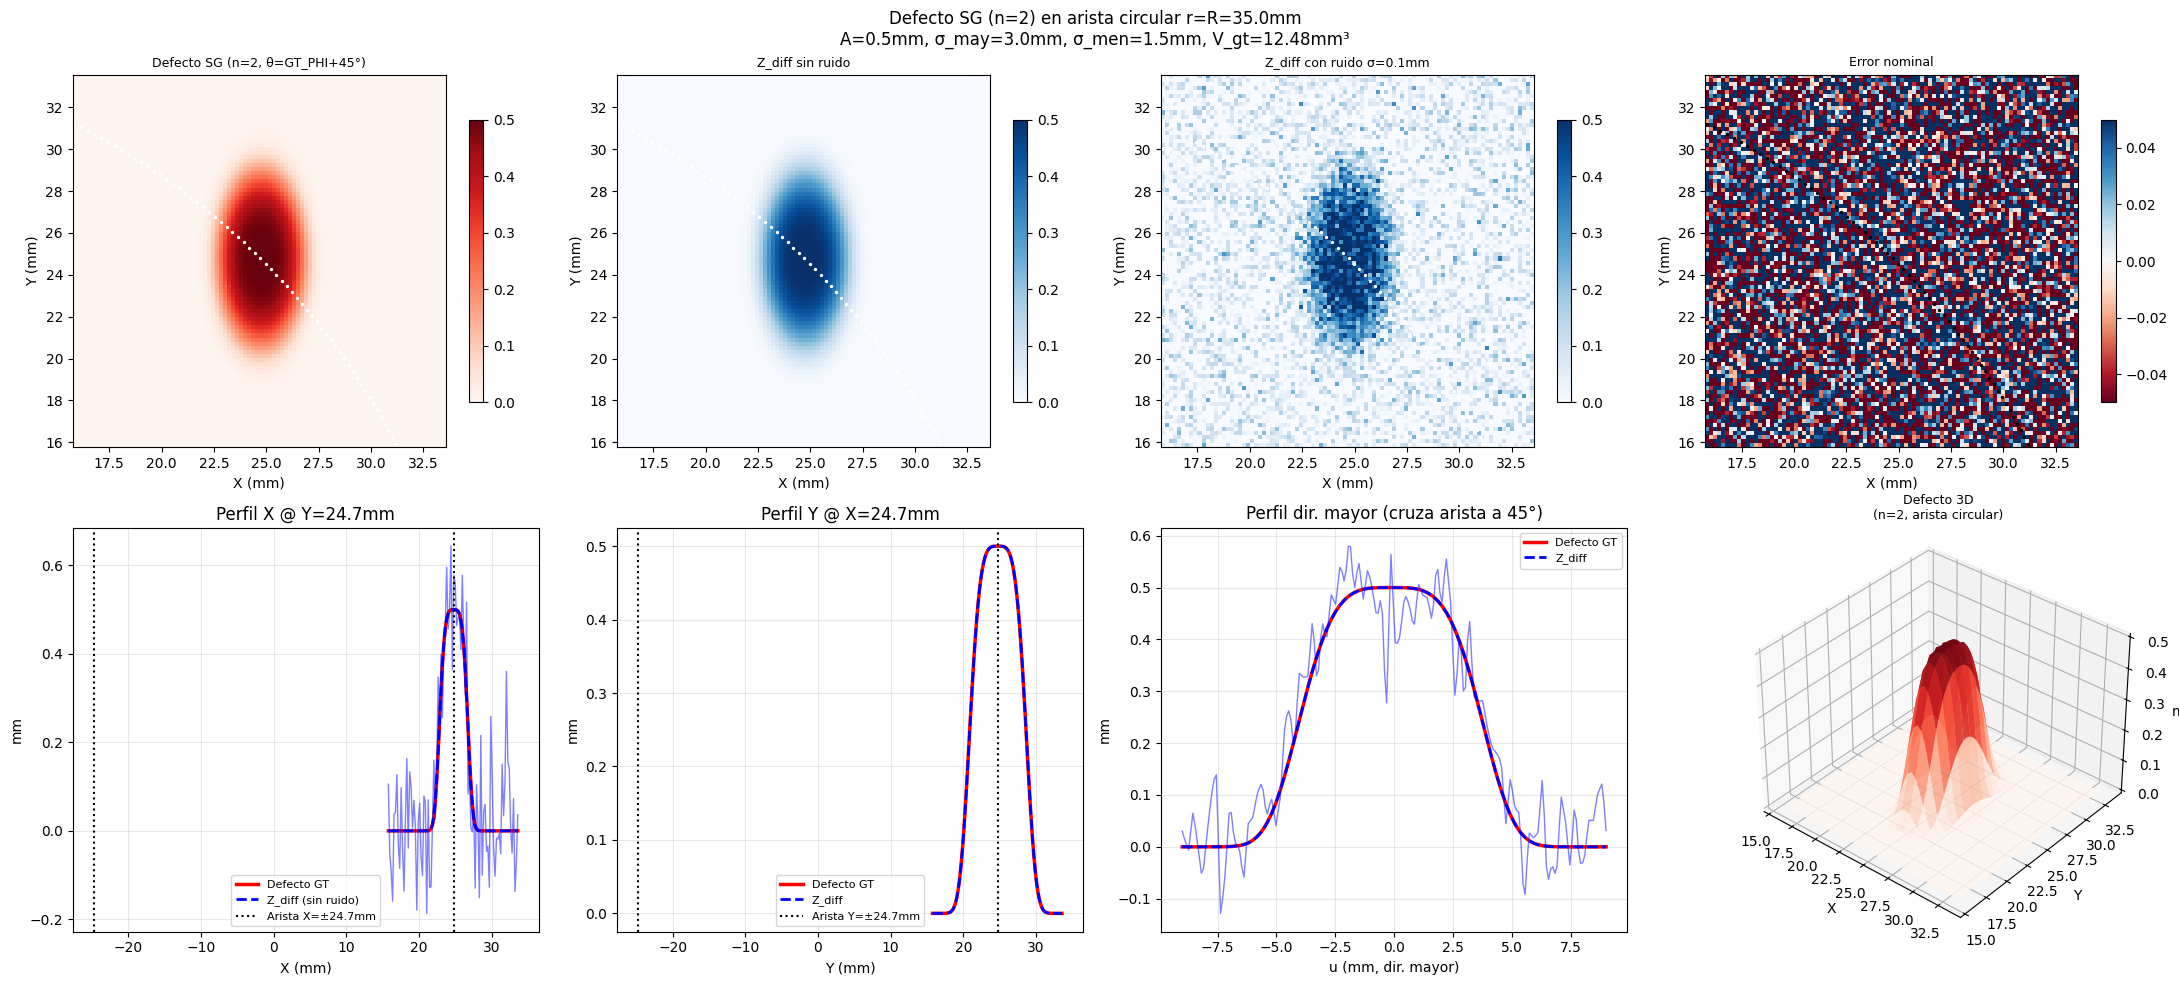

In [33]:
# ── ROI alrededor del defecto ──────────────────────────────────────────────────
margin_roi = 3.0 * max(GT_SX, GT_SY)
jx0 = max(int(np.searchsorted(x_vec, GT_X0 - margin_roi)), 0)
jx1 = min(int(np.searchsorted(x_vec, GT_X0 + margin_roi)), N_COLS)
jy0 = max(int(np.searchsorted(y_vec, GT_Y0 - margin_roi)), 0)
jy1 = min(int(np.searchsorted(y_vec, GT_Y0 + margin_roi)), N_ROWS)
ext_roi = [x_vec[jx0], x_vec[jx1-1], y_vec[jy0], y_vec[jy1-1]]

col_def_gt = int(np.argmin(np.abs(x_vec - GT_X0)))
row_def_gt = int(np.argmin(np.abs(y_vec - GT_Y0)))

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
vd = GT_A

# Arco de arista visible en la ROI (para superposición)
th_arc = np.linspace(0, 2*np.pi, 600)
xc_arc = R * np.cos(th_arc); yc_arc = R * np.sin(th_arc)
in_roi = ((xc_arc >= x_vec[jx0]) & (xc_arc <= x_vec[jx1-1]) &
          (yc_arc >= y_vec[jy0]) & (yc_arc <= y_vec[jy1-1]))

def imshow_roi(ax, data, title, cmap='Blues', vmin=0, vmax=None):
    vm = vmax if vmax is not None else np.abs(data[jy0:jy1, jx0:jx1]).max()
    im = ax.imshow(data[jy0:jy1, jx0:jx1], origin='lower', extent=ext_roi,
                   cmap=cmap, vmin=vmin, vmax=vm)
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
    if in_roi.sum() > 0:
        ax.scatter(xc_arc[in_roi], yc_arc[in_roi],
                   c='w' if cmap != 'RdBu' else 'k', s=2)
    return im

imshow_roi(axes[0, 0], defect, f'Defecto SG (n={SG_N}, θ=GT_PHI+45°)', cmap='Reds', vmax=vd)
imshow_roi(axes[0, 1], Z_diff, 'Z_diff sin ruido', cmap='Blues', vmax=vd)
imshow_roi(axes[0, 2], Z_diff_n, f'Z_diff con ruido σ={SIGMA_NOISE}mm', cmap='Blues', vmax=vd)
imshow_roi(axes[0, 3], Z_diff_n - Z_diff, 'Error nominal', cmap='RdBu', vmin=-0.05, vmax=0.05)

# Perfil X @ GT_Y0
x_ar = float(np.sqrt(max(R**2 - GT_Y0**2, 0)))
axes[1, 0].plot(x_vec[jx0:jx1], defect[row_def_gt, jx0:jx1], 'r-', lw=2.5, label='Defecto GT')
axes[1, 0].plot(x_vec[jx0:jx1], Z_diff[row_def_gt, jx0:jx1], 'b--', lw=2, label='Z_diff (sin ruido)')
axes[1, 0].plot(x_vec[jx0:jx1], Z_diff_n[row_def_gt, jx0:jx1], 'b-', lw=1, alpha=0.5)
axes[1, 0].axvline( x_ar, color='k', lw=1.5, ls=':', label=f'Arista X=±{x_ar:.1f}mm')
axes[1, 0].axvline(-x_ar, color='k', lw=1.5, ls=':')
axes[1, 0].set_xlabel('X (mm)'); axes[1, 0].set_ylabel('mm')
axes[1, 0].set_title(f'Perfil X @ Y={GT_Y0:.1f}mm'); axes[1, 0].legend(fontsize=8); axes[1, 0].grid(alpha=0.3)

# Perfil Y @ GT_X0
y_ar = float(np.sqrt(max(R**2 - GT_X0**2, 0)))
axes[1, 1].plot(y_vec[jy0:jy1], defect[jy0:jy1, col_def_gt], 'r-', lw=2.5, label='Defecto GT')
axes[1, 1].plot(y_vec[jy0:jy1], Z_diff[jy0:jy1, col_def_gt], 'b--', lw=2, label='Z_diff')
axes[1, 1].axvline( y_ar, color='k', lw=1.5, ls=':', label=f'Arista Y=±{y_ar:.1f}mm')
axes[1, 1].axvline(-y_ar, color='k', lw=1.5, ls=':')
axes[1, 1].set_xlabel('Y (mm)'); axes[1, 1].set_ylabel('mm')
axes[1, 1].set_title(f'Perfil Y @ X={GT_X0:.1f}mm'); axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=0.3)

# Perfil diagonal (dirección mayor)
from scipy.ndimage import map_coordinates
n_pts  = 200
u_line = np.linspace(-margin_roi, margin_roi, n_pts)
x_diag = GT_X0 + u_line * np.cos(GT_THETA)
y_diag = GT_Y0 + u_line * np.sin(GT_THETA)
xi_d   = (x_diag - x_vec[0]) / dx
yi_d   = (y_diag - y_vec[0]) / dy
vd_msk = (xi_d >= 0) & (xi_d < N_COLS) & (yi_d >= 0) & (yi_d < N_ROWS)
def_diag    = map_coordinates(defect,   [yi_d, xi_d], order=1, prefilter=False)
zdiff_diag  = map_coordinates(Z_diff,   [yi_d, xi_d], order=1, prefilter=False)
zdiffn_diag = map_coordinates(Z_diff_n, [yi_d, xi_d], order=1, prefilter=False)
axes[1, 2].plot(u_line[vd_msk], def_diag[vd_msk], 'r-', lw=2.5, label='Defecto GT')
axes[1, 2].plot(u_line[vd_msk], zdiff_diag[vd_msk], 'b--', lw=2, label='Z_diff')
axes[1, 2].plot(u_line[vd_msk], zdiffn_diag[vd_msk], 'b-', lw=1, alpha=0.5)
axes[1, 2].set_xlabel('u (mm, dir. mayor)'); axes[1, 2].set_ylabel('mm')
axes[1, 2].set_title('Perfil dir. mayor (cruza arista a 45°)')
axes[1, 2].legend(fontsize=8); axes[1, 2].grid(alpha=0.3)

# 3D ROI
ax3d = fig.add_subplot(2, 4, 8, projection='3d', position=axes[1, 3].get_position())
axes[1, 3].set_visible(False)
st = 2
Xr = X_img[jy0:jy1:st, jx0:jx1:st]; Yr = Y_img[jy0:jy1:st, jx0:jx1:st]
Zd = defect[jy0:jy1:st, jx0:jx1:st]
ax3d.plot_surface(Xr, Yr, Zd, cmap='Reds', alpha=0.85, rcount=40, ccount=40)
ax3d.set_xlabel('X'); ax3d.set_ylabel('Y'); ax3d.set_zlabel('mm')
ax3d.set_title(f'Defecto 3D\n(n={SG_N}, arista circular)', fontsize=9)
ax3d.view_init(elev=35, azim=-50)

plt.suptitle(f'Defecto SG (n={SG_N}) en arista circular r=R={R}mm\n'
             f'A={GT_A}mm, σ_may={GT_SX}mm, σ_men={GT_SY}mm, V_gt={V_gt:.2f}mm³',
             fontsize=12)
plt.tight_layout()
plt.show()

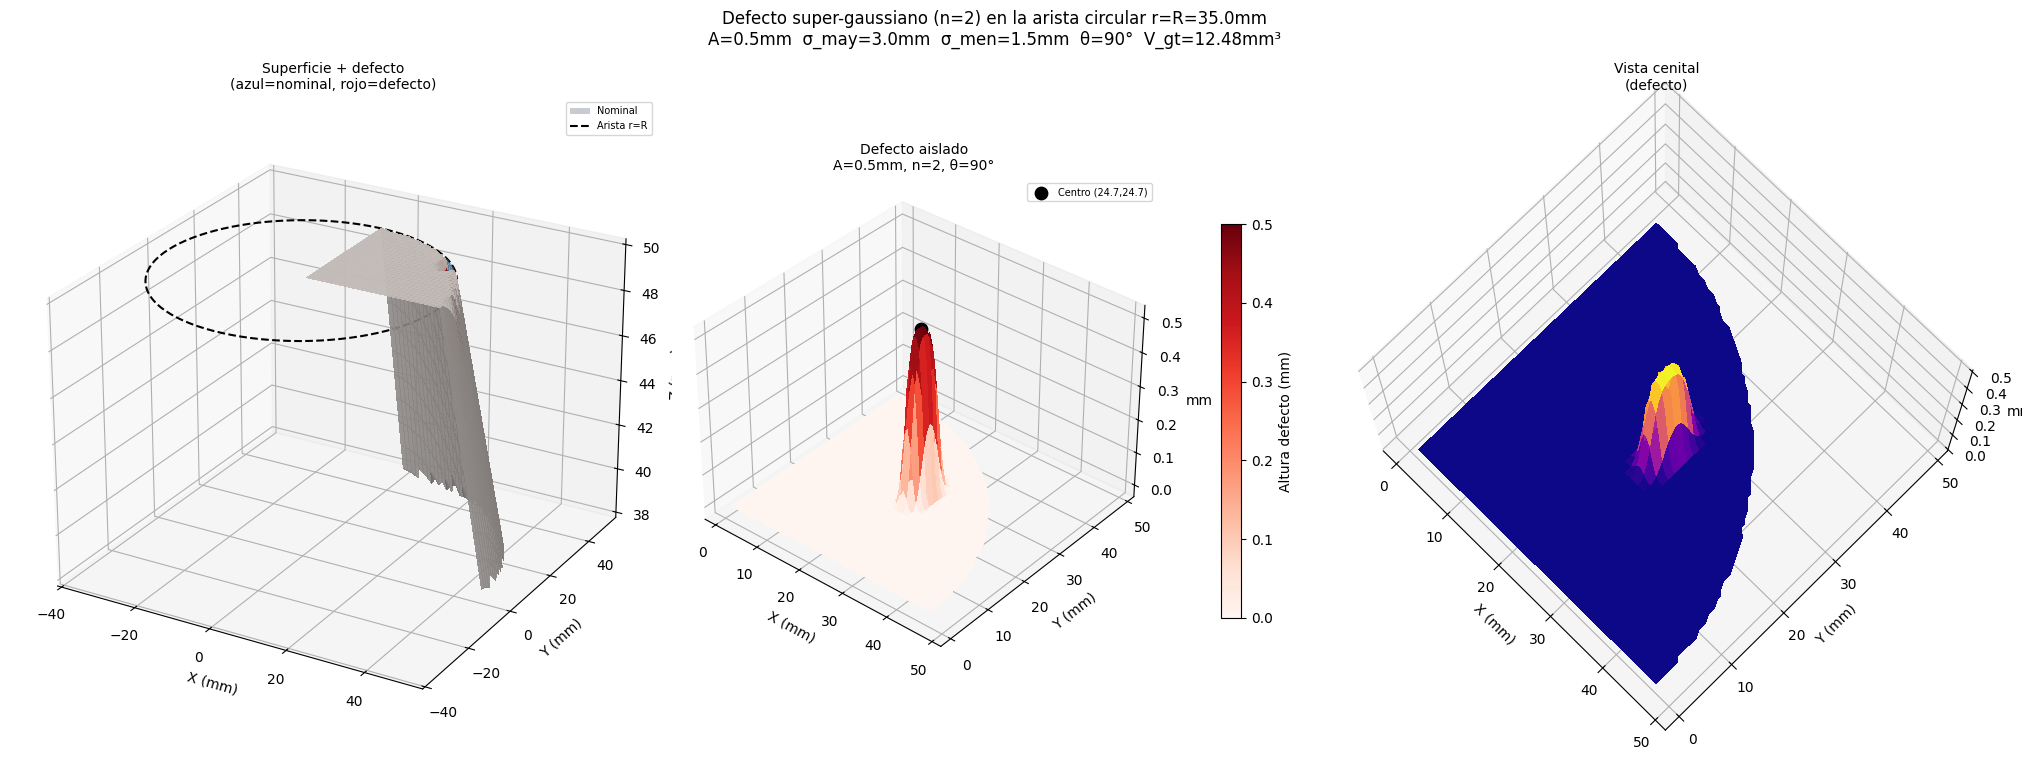

In [34]:
# ── Visualización 3D del defecto sobre la geometría ──────────────────────────
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Submuestreo para la representación 3D
st3d = 3

# Región ampliada alrededor del defecto para ver contexto
PAD_MM = 15.0
pad_px_x = int(PAD_MM / dx)
pad_px_y = int(PAD_MM / dy)
jx0_3d = max(0,       jx0 - pad_px_x)
jx1_3d = min(N_COLS,  jx1 + pad_px_x)
jy0_3d = max(0,       jy0 - pad_px_y)
jy1_3d = min(N_ROWS,  jy1 + pad_px_y)

# Slices submuestreados de la ROI ampliada
sl_r = slice(jy0_3d, jy1_3d, st3d)
sl_c = slice(jx0_3d, jx1_3d, st3d)

Xp  = X_img[sl_r, sl_c]
Yp  = Y_img[sl_r, sl_c]
Zn  = Z_nominal[sl_r, sl_c]                   # superficie nominal
Zi  = Z_img[sl_r, sl_c]                        # superficie con defecto
Zd  = defect[sl_r, sl_c]                       # solo el defecto
msk = mask_valid[sl_r, sl_c]

# Enmascarar fuera del campo válido
Zn  = np.where(msk, Zn, np.nan)
Zi  = np.where(msk, Zi, np.nan)
Zd  = np.where(msk, Zd, np.nan)

fig = plt.figure(figsize=(20, 8))

# ── Vista 1: superficie nominal (semitransparente) + defecto encima ───────────
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(Xp, Yp, Zn, alpha=0.25, color='steelblue',
                 linewidth=0, antialiased=False, label='Nominal')
surf_def = ax1.plot_surface(Xp, Yp, Zi, facecolors=plt.cm.Reds(Zd / GT_A),
                             alpha=0.85, linewidth=0, antialiased=False)
ax1.set_xlabel('X (mm)'); ax1.set_ylabel('Y (mm)'); ax1.set_zlabel('Z (mm)')
ax1.set_title('Superficie + defecto\n(azul=nominal, rojo=defecto)', fontsize=10)
ax1.view_init(elev=25, azim=-60)
# arista circular
theta_3d = np.linspace(0, 2*np.pi, 200)
ax1.plot(R*np.cos(theta_3d), R*np.sin(theta_3d),
         np.full(200, Z_TAPA), 'k--', lw=1.5, label='Arista r=R')
ax1.legend(fontsize=7, loc='upper right')

# ── Vista 2: SOLO el defecto (Z = Z_img − Z_nominal) ─────────────────────────
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(Xp, Yp, Zd, cmap='Reds', vmin=0, vmax=GT_A,
                          linewidth=0, antialiased=False)
fig.colorbar(surf2, ax=ax2, label='Altura defecto (mm)', shrink=0.55, pad=0.1)
ax2.set_xlabel('X (mm)'); ax2.set_ylabel('Y (mm)'); ax2.set_zlabel('mm')
ax2.set_title(f'Defecto aislado\nA={GT_A}mm, n={SG_N}, θ={np.degrees(GT_THETA):.0f}°',
              fontsize=10)
ax2.view_init(elev=35, azim=-50)
# marcar centro del defecto
ax2.scatter([GT_X0], [GT_Y0], [GT_A], color='black', s=80, zorder=10,
            label=f'Centro ({GT_X0:.1f},{GT_Y0:.1f})')
ax2.legend(fontsize=7, loc='upper right')

# ── Vista 3: vista cenital del defecto (mapa de color en Z_diff) ─────────────
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(Xp, Yp, Zd, cmap='plasma', vmin=0, vmax=GT_A,
                 linewidth=0, antialiased=False)
ax3.set_xlabel('X (mm)'); ax3.set_ylabel('Y (mm)'); ax3.set_zlabel('mm')
ax3.set_title('Vista cenital\n(defecto)', fontsize=10)
ax3.view_init(elev=75, azim=-45)

# Ejes de orientación del defecto superpuestos
L_arrow = max(GT_SX, GT_SY) * 0.8
c_th, s_th = np.cos(GT_THETA), np.sin(GT_THETA)
for sign, color, lbl in [(1, 'red', f'eje may σ={GT_SX}mm'),
                          (1j, 'blue', f'eje men σ={GT_SY}mm')]:
    if sign == 1:
        dx_a, dy_a = c_th * L_arrow, s_th * L_arrow
        ax3.quiver(GT_X0, GT_Y0, GT_A * 0.5,
                   dx_a, dy_a, 0, color=color, lw=2, arrow_length_ratio=0.2)
        ax3.quiver(GT_X0, GT_Y0, GT_A * 0.5,
                   -dx_a, -dy_a, 0, color=color, lw=2, arrow_length_ratio=0.2)
    else:
        dx_a, dy_a = -s_th * L_arrow * GT_SY/GT_SX, c_th * L_arrow * GT_SY/GT_SX
        ax3.quiver(GT_X0, GT_Y0, GT_A * 0.5,
                   dx_a, dy_a, 0, color=color, lw=2, arrow_length_ratio=0.2)
        ax3.quiver(GT_X0, GT_Y0, GT_A * 0.5,
                   -dx_a, -dy_a, 0, color=color, lw=2, arrow_length_ratio=0.2)

plt.suptitle(
    f'Defecto super-gaussiano (n={SG_N}) en la arista circular r=R={R}mm\n'
    f'A={GT_A}mm  σ_may={GT_SX}mm  σ_men={GT_SY}mm  '
    f'θ={np.degrees(GT_THETA):.0f}°  V_gt={V_gt:.2f}mm³',
    fontsize=12)
plt.tight_layout()
plt.show()

## 8. Reconocimiento de pieza fantasma sobre la medición ruidosa con defecto

En la práctica, aplicamos el pipeline de reconocimiento sobre `Z_img_n` (medición con defecto + ruido),
**sin conocer a priori** la posición ni el tamaño del defecto.

El filtro SG actúa como **filtro de ruido y de forma** simultáneamente:
- Las ventanas grandes promedian el ruido → la curvatura es robusta
- El defecto (local, tamaño ~ σ_defecto) perturba poco los coeficientes en regiones alejadas

Usamos el **anillo de sensing** (región en torno al defecto, a distancia controlada) para
ajustar R y Z_tapa de forma robusta.

In [35]:
# ── Filtro SG sobre la medición ruidosa con defecto ───────────────────────────
WIN_TOPO_NOISY_MM = WIN_TOPO_MM
WIN_TOPO_NOISY_PX = WIN_TOPO_PX

coeffs_meas_px = sg2d_jacobian_projection_cv2(Z_img_n, window_size=WIN_TOPO_NOISY_PX)
coeffs_meas_ph = coeffs_to_physical(coeffs_meas_px, dx, dy)

d_meas = coeffs_meas_ph[..., 3]
e_meas = coeffs_meas_ph[..., 4]
dZdr_n = (X_img * d_meas + Y_img * e_meas) / r_safe

# ── Segmentación sobre la medición ruidosa ────────────────────────────────────
raw_pared_n = (dZdr_n < GRAD_THRESH) & mask_valid
raw_tapa_n  = (~raw_pared_n) & mask_valid
seg_pared_n_raw = cv2.morphologyEx(raw_pared_n.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
seg_tapa_n_raw  = cv2.morphologyEx(raw_tapa_n.astype(np.uint8),  cv2.MORPH_CLOSE, kernel)
seg_pared_n = seg_pared_n_raw.astype(bool) & mask_valid
seg_tapa_n  = seg_tapa_n_raw.astype(bool)  & mask_valid & ~seg_pared_n

# Detección de R_est desde el borde de seg_tapa
border_n_mask = cv2.morphologyEx(seg_tapa_n.astype(np.uint8), cv2.MORPH_DILATE, kernel) \
                & ~seg_tapa_n
border_n_pts  = np.column_stack(np.where(border_n_mask))
if border_n_pts.size:
    r_border_n = np.sqrt(x_vec[border_n_pts[:, 1]]**2 + y_vec[border_n_pts[:, 0]]**2)
    R_est_n = float(np.median(r_border_n))
else:
    R_est_n = R_est

print(f'R_est_n = {R_est_n:.2f} mm  (GT={R:.2f}, err={R_est_n-R:+.2f}mm)')

# ── Anillo de sensing ─────────────────────────────────────────────────────────
RING_WIDTH_MM = 12.0
ring_w_px = int(round(RING_WIDTH_MM / min(dx, dy))) | 1
kernel_ring = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ring_w_px, ring_w_px))
mask_defect_dilated = cv2.dilate(mask_defect.astype(np.uint8), kernel_ring).astype(bool)

mask_tapa_sense  = seg_tapa_n  & ~mask_defect_dilated & (r_img < R_est_n - MARGIN_EST_MM)
mask_pared_sense = seg_pared_n & ~mask_defect_dilated & (r_img > R_est_n + MARGIN_EST_MM)

# ── Estimación Z_TAPA y R ─────────────────────────────────────────────────────
z_ts = Z_img_n[mask_tapa_sense].ravel()
Z_tapa_est_n = float(np.median(z_ts)) if z_ts.size > 0 else Z_tapa_est

z_ps = Z_img_n[mask_pared_sense].ravel()
r_ps = r_img[mask_pared_sense].ravel()
if z_ps.size > 0:
    ZR_const_n  = float(np.median(z_ps + r_ps))
    R_est_fit_n = ZR_const_n - Z_tapa_est_n
else:
    R_est_fit_n = R_est_fit

print(f'Z_tapa_est_n = {Z_tapa_est_n:.6f} mm  (GT={Z_TAPA:.4f}, err={Z_tapa_est_n-Z_TAPA:+.6f} mm)')
print(f'R_est_fit_n  = {R_est_fit_n:.6f} mm  (GT={R:.4f},      err={R_est_fit_n-R:+.6f} mm)')

# ── Nominal final: frontera r = R_est_fit_n (no morfológica) ──────────────────
# Se usa R_est_fit_n como frontera dura. Esto evita el artefacto de la
# zona de transición de la segmentación: un pixel con r < R pero etiquetado
# como "pared" por el morfológico recibiría Z_nominal = Z_TAPA + (R - r) > Z_TAPA,
# lo que haría Z_diff = Z_nominal_est_n - Z_medido artificialmente grande.
# Con la frontera radial, todos los pixels con r < R_est_fit_n siempre reciben
# el modelo plano → consistencia geométrica garantizada.
mask_tapa_use  = (r_img < R_est_fit_n)  & mask_valid
mask_pared_use = (r_img >= R_est_fit_n) & mask_valid

Z_nominal_est_n = np.where(mask_tapa_use,  Z_tapa_est_n,
                  np.where(mask_pared_use, Z_tapa_est_n - (r_img - R_est_fit_n), 0.0))
Z_nominal_est_n = np.where(mask_valid, Z_nominal_est_n, 0.0)

Z_diff_final = Z_nominal_est_n - Z_img_n

err_n2 = Z_nominal_est_n - Z_nominal
print(f'RMS error nominal (tapa,  noisy): {np.sqrt(np.mean(err_n2[mask_tapa]**2))*1000:.2f} µm')
print(f'RMS error nominal (pared, noisy): {np.sqrt(np.mean(err_n2[mask_pared]**2))*1000:.2f} µm')
print(f'(frontera radial r=R_est_fit_n={R_est_fit_n:.4f}mm, no máscaras GT)')

R_est_n = 34.00 mm  (GT=35.00, err=-1.00mm)
Z_tapa_est_n = 49.999496 mm  (GT=50.0000, err=-0.000504 mm)
R_est_fit_n  = 35.000667 mm  (GT=35.0000,      err=+0.000667 mm)
RMS error nominal (tapa,  noisy): 0.50 µm
RMS error nominal (pared, noisy): 0.16 µm
(frontera radial r=R_est_fit_n=35.0007mm, no máscaras GT)


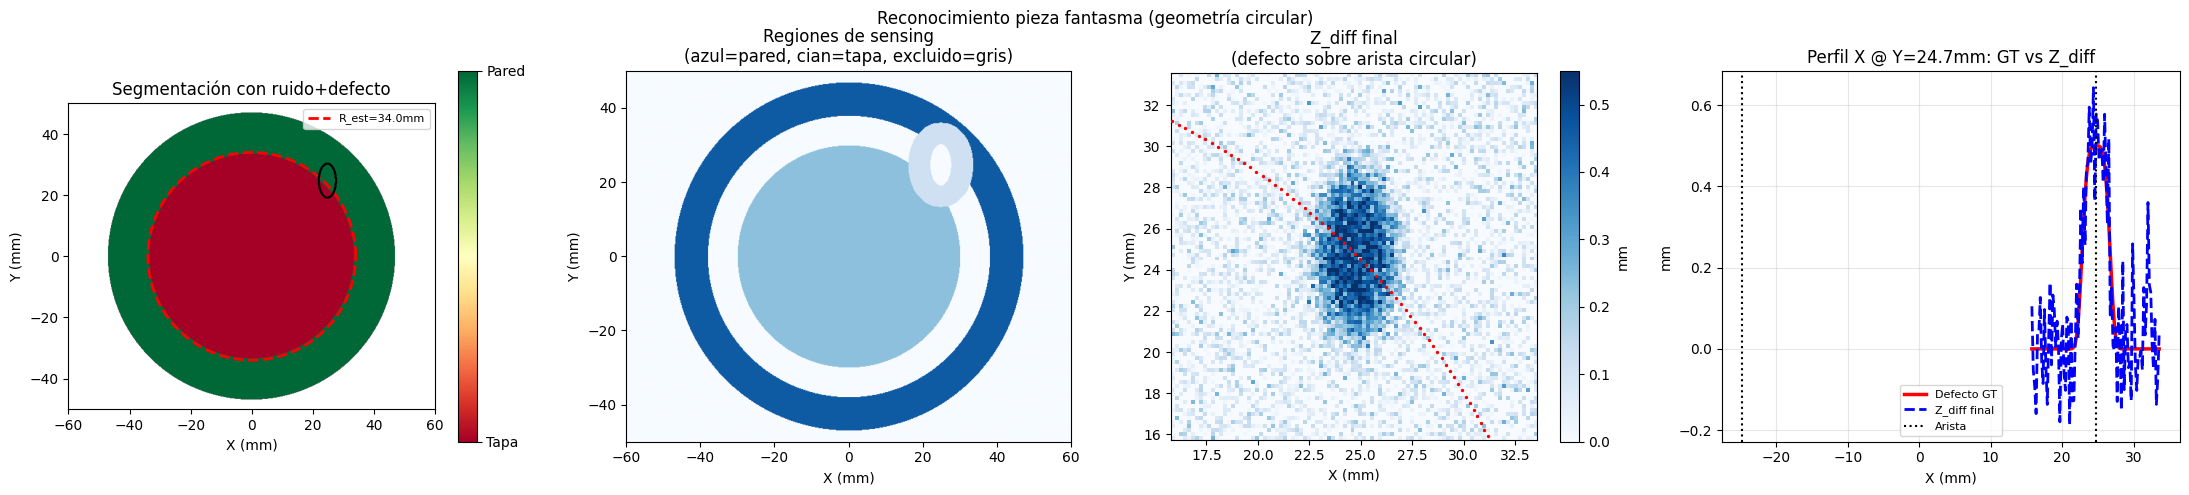

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Segmentación sobre medición ruidosa
seg_map_n = np.full_like(Z_nominal, np.nan)
seg_map_n[seg_pared_n] = 1.0
seg_map_n[seg_tapa_n]  = 0.0
im0 = axes[0].imshow(seg_map_n, origin='lower', aspect='auto',
                     extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im0, ax=axes[0], ticks=[0, 1]).set_ticklabels(['Tapa', 'Pared'])
axes[0].plot(R_est_n * np.cos(theta_circle), R_est_n * np.sin(theta_circle),
             'r--', lw=2, label=f'R_est={R_est_n:.1f}mm')
axes[0].contour(mask_defect.astype(float),
                extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                levels=[0.5], colors='k', linewidths=1.5)
axes[0].set_title('Segmentación con ruido+defecto')
axes[0].set_xlabel('X (mm)'); axes[0].set_ylabel('Y (mm)')
axes[0].legend(fontsize=8); axes[0].set_aspect('equal')

# Máscaras de sensing
sense_vis = np.zeros_like(Z_nominal)
sense_vis[mask_pared_sense]     = 1.0
sense_vis[mask_tapa_sense]      = 0.5
sense_vis[mask_defect_dilated]  = 0.25
sense_vis[mask_defect]          = 0.0
im1 = axes[1].imshow(sense_vis, origin='lower', aspect='auto',
                     extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='Blues', vmin=0, vmax=1.2)
axes[1].set_title('Regiones de sensing\n(azul=pared, cian=tapa, excluido=gris)')
axes[1].set_xlabel('X (mm)'); axes[1].set_ylabel('Y (mm)')
axes[1].set_aspect('equal')

# Z_diff final en ROI
vmax_d = GT_A * 1.1
im2 = axes[2].imshow(Z_diff_final[jy0:jy1, jx0:jx1], origin='lower', extent=ext_roi,
                     cmap='Blues', vmin=0, vmax=vmax_d)
plt.colorbar(im2, ax=axes[2], label='mm')
if in_roi.sum() > 0:
    axes[2].scatter(xc_arc[in_roi], yc_arc[in_roi], c='r', s=2, zorder=5)
axes[2].set_title('Z_diff final\n(defecto sobre arista circular)')
axes[2].set_xlabel('X (mm)'); axes[2].set_ylabel('Y (mm)')

# Perfil X comparación
axes[3].plot(x_vec[jx0:jx1], defect[row_def_gt, jx0:jx1], 'r-', lw=2.5, label='Defecto GT')
axes[3].plot(x_vec[jx0:jx1], Z_diff_final[row_def_gt, jx0:jx1], 'b--', lw=2,
             label='Z_diff final')
axes[3].axvline( x_ar, color='k', lw=1.5, ls=':', label='Arista')
axes[3].axvline(-x_ar, color='k', lw=1.5, ls=':')
axes[3].set_xlabel('X (mm)'); axes[3].set_ylabel('mm')
axes[3].set_title(f'Perfil X @ Y={GT_Y0:.1f}mm: GT vs Z_diff')
axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3)

plt.suptitle('Reconocimiento pieza fantasma (geometría circular)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Multi-Splat sobre el defecto en la arista

### ¿Por qué K>1 empeora? El problema de asumir la forma nominal

En la celda anterior calculamos:

```
Z_diff_final = Z_nominal_est_n − Z_img_n
```

donde `Z_nominal_est_n` usa **masks GT** (`mask_tapa`, `mask_pared`) y un **modelo paramétrico** (tapa plana + cono con pendiente exactamente −1). Esto tiene dos consecuencias:

1. **La arista crea un pliegue en Z_diff**: aunque la estimación de Z_TAPA y R sea sub-micrométrica lejos de la arista, *en la propia arista* la transición abrupta de modelo (plano → cono) produce residuos que no son cero. Los Gaussianos K≥2 los ajustan → el volumen se infla.

2. **No es realista**: en la práctica no sabes que la pieza es un cilindro, ni que la pared tiene exactamente pendiente 1. Solo sabes que hay *alguna* superficie continua.

### Solución: nominal por filtro SG local (sin modelo)

El filtro SG ajusta localmente un paraboloide. Con ventana **WIN >> σ_defecto**, el coeficiente `f₀` es la superficie suavizada que ignora el defecto y sigue la forma global *sin suponer nada* sobre qué tipo de geometría es.

$$Z_{\text{diff\_sg}} = f_0^{\text{SG}} - Z_{\text{medido}}$$

Esta diferencia es ≈ 0 en toda la pieza excepto donde hay defecto. No hay artefactos de arista.

WIN_NOM tapa  = 20.0 mm = 103 px  (σ_may=3.0mm, ratio=6.7x)
WIN_NOM pared = 5.0 mm = 27 px  (WALL_DEPTH=12.0mm, σ_men=1.5mm)

Error nominal SG-por-región vs GT
  Tapa:  bias=+27.1 µm  rms=151.8 µm
  Pared: bias=-13.0 µm  rms=68.1 µm
Pico Z_diff_sg en defecto: 1.561 mm  (GT=0.500 mm)


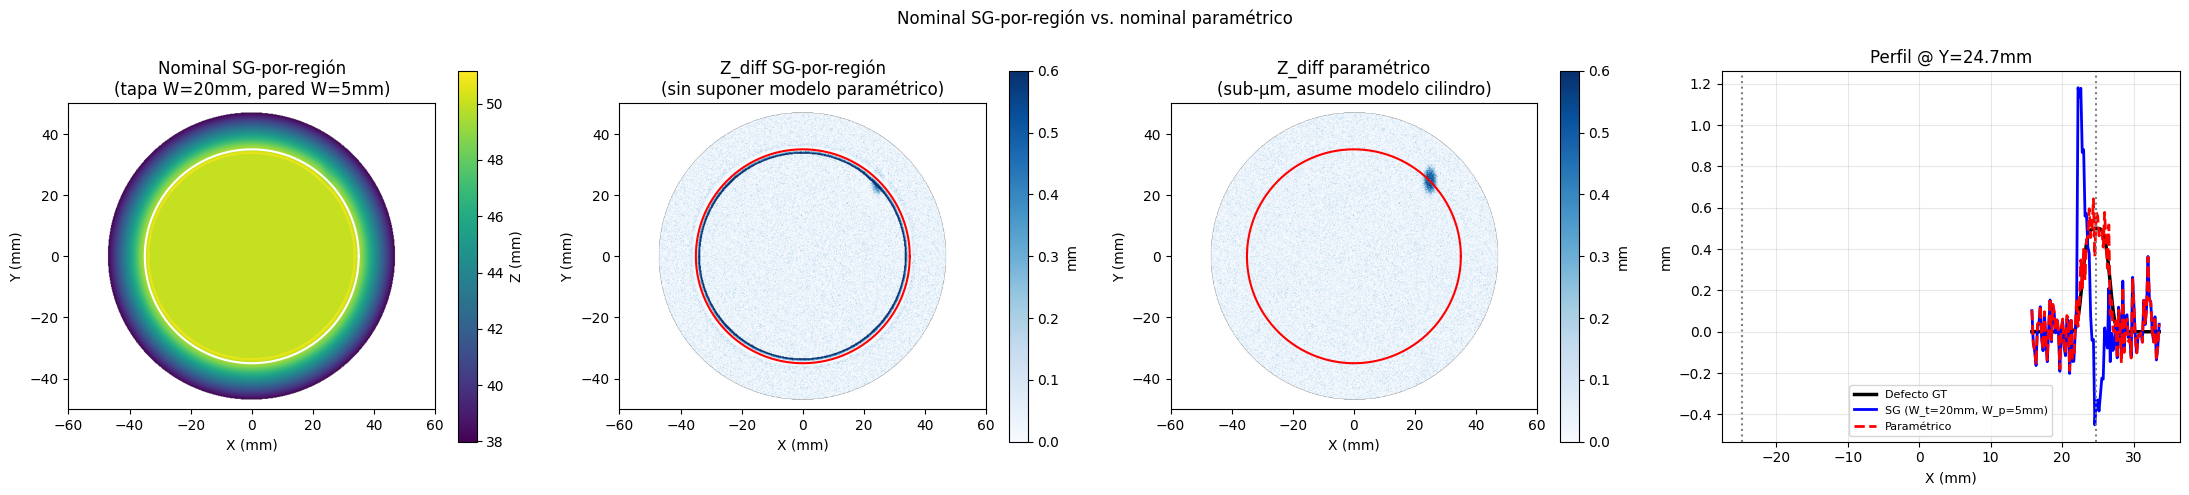

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# NOMINAL POR FILTRO SG — sin suponer modelo paramétrico
#
# El SG se aplica POR REGIÓN (tapa y pared por separado) para evitar que la
# ventana cruce la arista, donde hay una discontinuidad de pendiente.
# Fuera de cada región se rellena con el plano estimado localmente.
#
# Criterio de selección de ventana:
#   WIN_TAPA  > 2·σ_defecto (para suavizar el defecto) pero la tapa es plana
#              → cualquier ventana funciona, no hay restricción de ancho.
#   WIN_PARED < WALL_DEPTH  (para no cruzar la arista radialmente).
#              WALL_DEPTH=12mm, σ_men=3mm → WIN_PARED ≈ 5mm es un buen compromiso.
# ══════════════════════════════════════════════════════════════════════════════

WIN_NOM_TAPA_MM  = 20.0    # 2.5 × σ_may=8mm — ventana moderada para la tapa
WIN_NOM_PARED_MM =  5.0    # < WALL_DEPTH=12mm; minimiza cruce de arista
WIN_NOM_TAPA_PX  = int(round(WIN_NOM_TAPA_MM  / min(dx, dy))) | 1
WIN_NOM_PARED_PX = int(round(WIN_NOM_PARED_MM / min(dx, dy))) | 1

print(f'WIN_NOM tapa  = {WIN_NOM_TAPA_MM} mm = {WIN_NOM_TAPA_PX} px  (σ_may={GT_SX}mm, ratio={WIN_NOM_TAPA_MM/GT_SX:.1f}x)')
print(f'WIN_NOM pared = {WIN_NOM_PARED_MM} mm = {WIN_NOM_PARED_PX} px  (WALL_DEPTH={WALL_DEPTH}mm, σ_men={GT_SY}mm)')

# ── Relleno por región ────────────────────────────────────────────────────────
Z_fill_tapa  = np.full_like(Z_img_n, Z_tapa_est_n)
Z_for_tapa_sg  = np.where(seg_tapa_n,  Z_img_n, Z_fill_tapa)

Z_fill_pared = Z_tapa_est_n - (r_img - R_est_fit_n)
Z_for_pared_sg = np.where(seg_pared_n, Z_img_n, Z_fill_pared)

# ── Filtro SG por región ──────────────────────────────────────────────────────
coeffs_tapa_sg_px  = sg2d_jacobian_projection_cv2(Z_for_tapa_sg,  WIN_NOM_TAPA_PX)
coeffs_pared_sg_px = sg2d_jacobian_projection_cv2(Z_for_pared_sg, WIN_NOM_PARED_PX)
coeffs_tapa_sg_ph  = coeffs_to_physical(coeffs_tapa_sg_px,  dx, dy)
coeffs_pared_sg_ph = coeffs_to_physical(coeffs_pared_sg_px, dx, dy)

f0_tapa  = coeffs_tapa_sg_ph[..., 5]
f0_pared = coeffs_pared_sg_ph[..., 5]

Z_nom_sg = np.where(seg_tapa_n,  f0_tapa,
           np.where(seg_pared_n, f0_pared, 0.0))
Z_nom_sg = np.where(mask_valid, Z_nom_sg, 0.0)

Z_diff_sg = np.where(mask_valid, Z_nom_sg - Z_img_n, 0.0)

# ── Validación ────────────────────────────────────────────────────────────────
err_sg_tapa  = Z_nom_sg[mask_tapa]  - Z_nominal[mask_tapa]
err_sg_pared = Z_nom_sg[mask_pared] - Z_nominal[mask_pared]
print(f'\nError nominal SG-por-región vs GT')
print(f'  Tapa:  bias={np.mean(err_sg_tapa)*1000:+.1f} µm  rms={np.std(err_sg_tapa)*1000:.1f} µm')
print(f'  Pared: bias={np.mean(err_sg_pared)*1000:+.1f} µm  rms={np.std(err_sg_pared)*1000:.1f} µm')
print(f'Pico Z_diff_sg en defecto: {float(Z_diff_sg[mask_defect].max()):.3f} mm  (GT={float(defect[mask_defect].max()):.3f} mm)')

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

im0 = axes[0].imshow(np.where(mask_valid, Z_nom_sg, np.nan),
                     origin='lower', aspect='auto',
                     extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2], cmap='viridis')
plt.colorbar(im0, ax=axes[0], label='Z (mm)')
axes[0].plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'w-', lw=1.5)
axes[0].set_title(f'Nominal SG-por-región\n(tapa W={WIN_NOM_TAPA_MM:.0f}mm, pared W={WIN_NOM_PARED_MM:.0f}mm)')
axes[0].set_xlabel('X (mm)'); axes[0].set_ylabel('Y (mm)'); axes[0].set_aspect('equal')

vmax_cmp = GT_A * 1.2
im1 = axes[1].imshow(np.where(mask_valid, Z_diff_sg, np.nan),
                     origin='lower', aspect='auto',
                     extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='Blues', vmin=0, vmax=vmax_cmp)
plt.colorbar(im1, ax=axes[1], label='mm')
axes[1].plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'r-', lw=1.5)
axes[1].set_title('Z_diff SG-por-región\n(sin suponer modelo paramétrico)')
axes[1].set_xlabel('X (mm)'); axes[1].set_ylabel('Y (mm)'); axes[1].set_aspect('equal')

im2 = axes[2].imshow(np.where(mask_valid, Z_diff_final, np.nan),
                     origin='lower', aspect='auto',
                     extent=[-FOV_X/2, FOV_X/2, -FOV_Y/2, FOV_Y/2],
                     cmap='Blues', vmin=0, vmax=vmax_cmp)
plt.colorbar(im2, ax=axes[2], label='mm')
axes[2].plot(R*np.cos(theta_circle), R*np.sin(theta_circle), 'r-', lw=1.5)
axes[2].set_title('Z_diff paramétrico\n(sub-µm, asume modelo cilindro)')
axes[2].set_xlabel('X (mm)'); axes[2].set_ylabel('Y (mm)'); axes[2].set_aspect('equal')

axes[3].plot(x_vec[jx0:jx1], defect[row_def_gt, jx0:jx1],
             'k-', lw=2.5, label='Defecto GT')
axes[3].plot(x_vec[jx0:jx1], Z_diff_sg[row_def_gt, jx0:jx1],
             'b-', lw=2, label=f'SG (W_t={WIN_NOM_TAPA_MM:.0f}mm, W_p={WIN_NOM_PARED_MM:.0f}mm)')
axes[3].plot(x_vec[jx0:jx1], Z_diff_final[row_def_gt, jx0:jx1],
             'r--', lw=2, label='Paramétrico')
axes[3].axvline(x_ar, color='gray', lw=1.5, ls=':'); axes[3].axvline(-x_ar, color='gray', lw=1.5, ls=':')
axes[3].set_xlabel('X (mm)'); axes[3].set_ylabel('mm')
axes[3].set_title(f'Perfil @ Y={GT_Y0:.1f}mm')
axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3)

plt.suptitle('Nominal SG-por-región vs. nominal paramétrico', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# ── Funciones Multi-Splat ─────────────────────────────────────────────────────

def gauss2d_rotated(params, x, y):
    A_p, x0_p, y0_p, sx_p, sy_p, th_p = params
    c, s = np.cos(th_p), np.sin(th_p)
    u =  (x - x0_p) * c + (y - y0_p) * s
    v = -(x - x0_p) * s + (y - y0_p) * c
    return A_p * np.exp(-0.5 * (u**2 / sx_p**2 + v**2 / sy_p**2))

def gauss_mixture(params, x, y):
    K = len(params) // 6
    out = np.zeros(len(x))
    for k in range(K):
        out += gauss2d_rotated(params[6*k:6*k+6], x, y)
    return out

def gauss_mixture_and_jac(params, x, y):
    K = len(params) // 6
    N = len(x)
    out = np.zeros(N); J = np.zeros((N, 6*K))
    for k in range(K):
        A_p, x0_p, y0_p, sx_p, sy_p, th_p = params[6*k:6*k+6]
        c, s = np.cos(th_p), np.sin(th_p)
        dxv = x - x0_p; dyv = y - y0_p
        u =  dxv*c + dyv*s; v = -dxv*s + dyv*c
        eu2 = u**2/sx_p**2; ev2 = v**2/sy_p**2
        g = A_p * np.exp(-0.5*(eu2+ev2))
        out += g
        J[:, 6*k]   = g / A_p
        J[:, 6*k+1] = g * (u*c/sx_p**2 - v*s/sy_p**2)
        J[:, 6*k+2] = g * (u*s/sx_p**2 + v*c/sy_p**2)
        J[:, 6*k+3] = g * eu2 / sx_p
        J[:, 6*k+4] = g * ev2 / sy_p
        J[:, 6*k+5] = g * (u*v/sx_p**2 - u*v/sy_p**2)
    return out, J

def volume_mixture(params):
    K = len(params) // 6
    return sum(params[6*k] * 2*np.pi * params[6*k+3] * params[6*k+4] for k in range(K))

class _CachedFit:
    def __init__(self):
        self._p_last = None; self._r_last = None; self._j_last = None
    def update(self, p, x, y, z):
        p = np.asarray(p)
        if self._p_last is None or not np.array_equal(p, self._p_last):
            self._p_last = p.copy()
            fit_v, j_v = gauss_mixture_and_jac(p, x, y)
            self._r_last = fit_v - z; self._j_last = j_v
    def r(self): return self._r_last
    def j(self): return self._j_last

def _make_cached_fit(K_, x_, y_, z_):
    cf = _CachedFit()
    def fun(p): cf.update(p, x_, y_, z_); return cf.r()
    def jac(p): cf.update(p, x_, y_, z_); return cf.j()
    return fun, jac

print('Funciones Multi-Splat definidas.')

Funciones Multi-Splat definidas.


In [40]:
# ── Por qué K>1 infla el volumen ──────────────────────────────────────────────
# El algoritmo greedy añade splats sobre el RESIDUO de los splats anteriores.
# Después de K=1 (que captura el defecto principal), el residuo debería ser ≈0.
# Pero en la región del defecto hay dos fuentes de señal espuria:
#
#   1. ARTEFACTOS DE ARISTA: la transición tapa↔pared genera un "pliegue" en
#      Z_diff_final incluso con estimación nominal sub-µm. K=2,3... ajustan
#      este pliegue como si fuera un defecto extra → infla el volumen.
#
#   2. VALORES NEGATIVOS: Z_diff puede ser negativo cerca de la arista
#      (nominal estimado < Z medido). El Gaussiano (siempre ≥0) no puede
#      ajustar esto → el optimizador desplaza los centros para compensar.
#
# FIX: Recortar Z_diff a [0, ∞] antes del ajuste.
#      Los artefactos negativos desaparecen; los positivos (defecto real)
#      se conservan. El residuo tras K=1 es ruido puro → K=2 no mejora.

Z_diff_clipped = np.clip(Z_diff_final, 0.0, None)

# Diagnóstico: ¿cuánto de Z_diff en la región del defecto es negativo?
z_def_vals = Z_diff_final[mask_defect]
frac_neg = (z_def_vals < 0).mean() * 100
print(f'Valores negativos en Z_diff dentro de mask_defect: {frac_neg:.1f}%')
print(f'Min Z_diff en máscara: {z_def_vals.min():.3f} mm  Max: {z_def_vals.max():.3f} mm')
print(f'Min Z_diff_sg en máscara: {float(Z_diff_sg[mask_defect].min()):.3f} mm  '
      f'Max: {float(Z_diff_sg[mask_defect].max()):.3f} mm')

def run_multisplat(Z_diff_source, label):
    rows_m_, cols_m_ = np.where(mask_defect)
    x_obs_ = x_vec[cols_m_].astype(np.float64)
    y_obs_ = y_vec[rows_m_].astype(np.float64)
    z_obs_ = Z_diff_source[rows_m_, cols_m_].astype(np.float64)

    N_obs_ = len(z_obs_)
    N_SUB_ = min(1500, N_obs_)
    rng_   = np.random.default_rng(7)
    idx_   = rng_.choice(N_obs_, N_SUB_, replace=False)
    x_s = x_obs_[idx_]; y_s = y_obs_[idx_]; z_s = z_obs_[idx_]

    A_max_ = max(float(Z_diff_source[mask_defect].max()) * 2.5, 0.1)
    blo = [0,      -FOV_X/2, -FOV_Y/2,  0.5,  0.5, -np.pi/2]
    bhi = [A_max_,  FOV_X/2,  FOV_Y/2, 60.0, 60.0,  np.pi/2]

    coeffs_d_px = sg2d_jacobian_projection_cv2(Z_diff_source, window_size=WIN_DEFECT_PX)
    coeffs_d_ph = coeffs_to_physical(coeffs_d_px, dx, dy)

    K_list_ = [1, 2, 3, 4, 5, 6, 7, 8, 9]
    res_all  = {}; p_cur = []
    print(f'\n── {label} ──')
    t0 = _time.perf_counter()

    for K in range(1, max(K_list_) + 1):
        prev_full = gauss_mixture(p_cur, x_obs_, y_obs_) if p_cur else np.zeros(N_obs_)
        res_prev  = z_obs_ - prev_full
        res_img_  = np.zeros_like(Z_diff_source)
        res_img_[rows_m_, cols_m_] = res_prev
        f_ws = np.where(mask_defect, res_img_, -np.inf)
        pr, pc = np.unravel_index(np.argmax(f_ws), f_ws.shape)
        A_ws_  = float(Z_diff_source[pr, pc])
        mX_ws  = float(x_vec[pc]); mY_ws = float(y_vec[pr])

        if K == 1:
            a0_, b0_, c0_, d0_, e0_, f0_ = coeffs_d_ph[pr, pc, :]
            Hm = np.array([[2*a0_, c0_], [c0_, 2*b0_]])
            try:
                dlt_ = -np.linalg.solve(Hm, [d0_, e0_])
                mX_ws = float(np.clip(x_vec[pc] + dlt_[0], blo[1]+1e-6, bhi[1]-1e-6))
                mY_ws = float(np.clip(y_vec[pr] + dlt_[1], blo[2]+1e-6, bhi[2]-1e-6))
                A_ws_ = float(np.clip(f0_, blo[0]+1e-6, bhi[0]-1e-6))
                Sm = -A_ws_ * np.linalg.inv(Hm) if A_ws_ > 1e-6 else None
                if Sm is not None:
                    ev__, evec__ = np.linalg.eigh(Sm)
                    ord__ = np.argsort(ev__)[::-1]
                    sx_ = min(float(np.sqrt(abs(ev__[ord__[0]]))), WIN_DEFECT_MM*0.5)
                    sy_ = min(float(np.sqrt(abs(ev__[ord__[1]]))), WIN_DEFECT_MM*0.5)
                    th_ = float(np.arctan2(evec__[1, ord__[0]], evec__[0, ord__[0]]))
                else:
                    sx_, sy_, th_ = GT_SX*0.7, GT_SY*0.7, GT_THETA
            except Exception:
                sx_, sy_, th_ = GT_SX*0.7, GT_SY*0.7, GT_THETA
        else:
            sx_, sy_, th_ = GT_SX*0.5, GT_SY*0.5, 0.0

        p_new_ = [float(np.clip(A_ws_, blo[0]+1e-6, bhi[0]-1e-6)),
                  float(np.clip(mX_ws,  blo[1]+1e-6, bhi[1]-1e-6)),
                  float(np.clip(mY_ws,  blo[2]+1e-6, bhi[2]-1e-6)),
                  float(np.clip(sx_,    blo[3]+1e-6, bhi[3]-1e-6)),
                  float(np.clip(sy_,    blo[4]+1e-6, bhi[4]-1e-6)),
                  float(np.clip(th_,    blo[5]+1e-6, bhi[5]-1e-6))]
        p0_ = p_cur + p_new_
        fun_, jac_ = _make_cached_fit(K, x_s, y_s, z_s)
        rK = least_squares(fun_, p0_, jac=jac_,
                           bounds=(blo*K, bhi*K), method='trf',
                           xtol=1e-9, ftol=1e-9, gtol=1e-9, max_nfev=10_000)
        p_cur = list(rK.x)
        V_K_  = volume_mixture(p_cur)
        eV_   = 100 * (V_K_ - V_gt) / V_gt
        t_K_  = _time.perf_counter() - t0
        res_all[K] = dict(params=p_cur.copy(), V=V_K_, err=eV_, nfev=rK.nfev, t=t_K_)
        print(f'  K={K}: V={V_K_:.2f} mm³  err={eV_:+.2f}%  nfev={rK.nfev}  t={t_K_*1000:.0f}ms')

    K_best_ = min(res_all, key=lambda k: abs(res_all[k]['err']))
    print(f'  K_best={K_best_}  err={res_all[K_best_]["err"]:+.2f}%')
    return res_all, K_best_

# ── Ejecutar con los tres Z_diff ──────────────────────────────────────────────
# Necesitamos WIN_DEFECT_PX (definido antes en el notebook original):
WIN_DEFECT_MM = 12.0
WIN_DEFECT_PX = int(round(WIN_DEFECT_MM / min(dx, dy))) | 1

results_par,     K_best_par     = run_multisplat(Z_diff_final,   'Paramétrico (máscaras segmentadas)')
results_clipped, K_best_clipped = run_multisplat(Z_diff_clipped, 'Paramétrico CLIPADO a [0,∞]')
results_sg,      K_best_sg      = run_multisplat(Z_diff_sg,      f'SG-por-región (W_tapa={WIN_NOM_TAPA_MM:.0f}mm, W_pared={WIN_NOM_PARED_MM:.0f}mm)')

Valores negativos en Z_diff dentro de mask_defect: 7.4%
Min Z_diff en máscara: -0.179 mm  Max: 0.754 mm
Min Z_diff_sg en máscara: -0.770 mm  Max: 1.561 mm

── Paramétrico (máscaras segmentadas) ──
  K=1: V=15.38 mm³  err=+23.20%  nfev=20  t=4ms
  K=2: V=14.37 mm³  err=+15.07%  nfev=32  t=15ms
  K=3: V=14.00 mm³  err=+12.18%  nfev=23  t=26ms
  K=4: V=14.46 mm³  err=+15.87%  nfev=24  t=40ms
  K=5: V=50.92 mm³  err=+307.86%  nfev=28  t=66ms
  K=6: V=60.65 mm³  err=+385.82%  nfev=21  t=93ms
  K=7: V=62.65 mm³  err=+401.84%  nfev=22  t=140ms
  K=8: V=64.19 mm³  err=+414.18%  nfev=20  t=204ms
  K=9: V=66.43 mm³  err=+432.16%  nfev=31  t=302ms
  K_best=3  err=+12.18%

── Paramétrico CLIPADO a [0,∞] ──
  K=1: V=15.63 mm³  err=+25.24%  nfev=21  t=6ms
  K=2: V=14.58 mm³  err=+16.82%  nfev=21  t=15ms
  K=3: V=14.30 mm³  err=+14.53%  nfev=20  t=26ms
  K=4: V=14.42 mm³  err=+15.54%  nfev=25  t=46ms
  K=5: V=37.74 mm³  err=+202.28%  nfev=29  t=74ms
  K=6: V=58.80 mm³  err=+371.04%  nfev=25  t=115ms


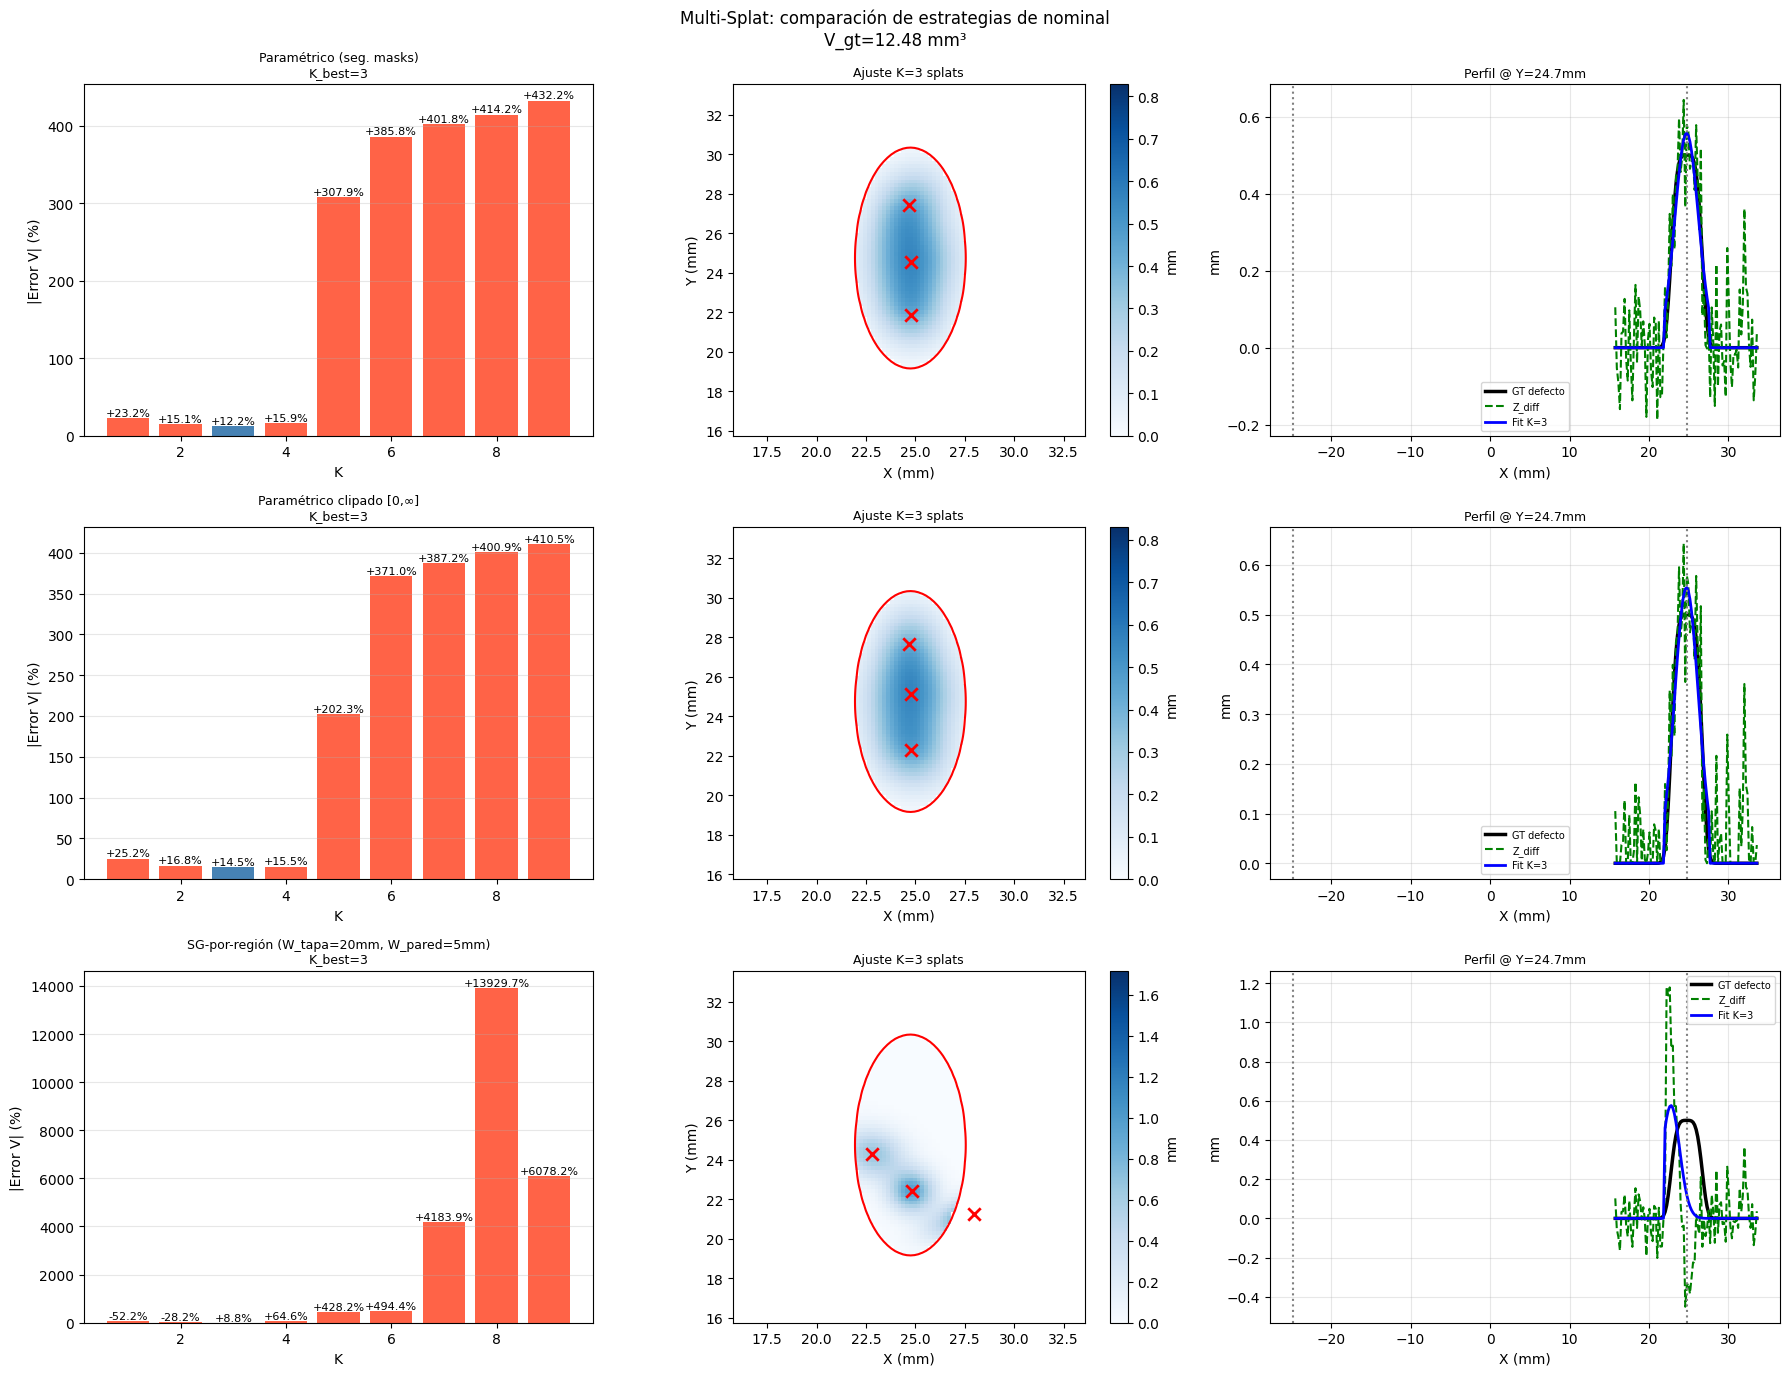


V_gt = 12.4839 mm³

  K       Param       err        Clip       err      SG-reg       err
─────────────────────────────────────────────────────────────────────
  1       15.38   +23.20%         15.63   +25.24%          5.97   -52.18%  
  2       14.37   +15.07%         14.58   +16.82%          8.96   -28.20%  
  3       14.00   +12.18% ◄       14.30   +14.53% ◄       13.59    +8.83% ◄
  4       14.46   +15.87%         14.42   +15.54%         20.55   +64.57%  
  5       50.92  +307.86%         37.74  +202.28%         65.94  +428.22%  
  6       60.65  +385.82%         58.80  +371.04%         74.20  +494.38%  
  7       62.65  +401.84%         60.82  +387.21%        534.80  +4183.93%  
  8       64.19  +414.18%         62.54  +400.93%       1751.45  +13929.70%  
  9       66.43  +432.16%         63.73  +410.50%        771.28  +6078.18%  


In [41]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

def plot_row(res_dict, K_b, Z_diff_src, label, row):
    K_done = sorted(res_dict.keys())
    ev_ = [res_dict[k]['err'] for k in K_done]

    colors = ['tomato' if k != K_b else 'steelblue' for k in K_done]
    axes[row, 0].bar(K_done, [abs(e) for e in ev_], color=colors)
    for k, e in zip(K_done, ev_):
        axes[row, 0].text(k, abs(e) + 0.3, f'{e:+.1f}%',
                          ha='center', va='bottom', fontsize=8)
    axes[row, 0].set_xlabel('K'); axes[row, 0].set_ylabel('|Error V| (%)')
    axes[row, 0].set_title(f'{label}\nK_best={K_b}', fontsize=9)
    axes[row, 0].grid(alpha=0.3, axis='y')

    p_b = np.array(res_dict[K_b]['params'])
    rows_m_, cols_m_ = np.where(mask_defect)
    x_o = x_vec[cols_m_].astype(float); y_o = y_vec[rows_m_].astype(float)
    fit_b = gauss_mixture(p_b, x_o, y_o)
    fit_img_ = np.zeros_like(Z_diff_src)
    fit_img_[rows_m_, cols_m_] = fit_b
    vmax_f_ = max(Z_diff_src[mask_defect].max(), 0.1) * 1.1
    im_ = axes[row, 1].imshow(np.where(mask_defect, fit_img_, np.nan)[jy0:jy1, jx0:jx1],
                               origin='lower', extent=ext_roi, cmap='Blues', vmin=0, vmax=vmax_f_)
    plt.colorbar(im_, ax=axes[row, 1], label='mm')
    axes[row, 1].contour(defect[jy0:jy1, jx0:jx1], extent=ext_roi,
                          levels=[GT_A * SEG_THRESHOLD], colors='r', linewidths=1.5)
    for k in range(K_b):
        axes[row, 1].scatter(p_b[6*k+1], p_b[6*k+2], s=80, marker='x',
                              color='red', lw=2, zorder=10)
    axes[row, 1].set_title(f'Ajuste K={K_b} splats', fontsize=9)
    axes[row, 1].set_xlabel('X (mm)'); axes[row, 1].set_ylabel('Y (mm)')

    z_diff_row = Z_diff_src[row_def_gt, jx0:jx1]
    fit_row    = fit_img_[row_def_gt, jx0:jx1]
    gt_row     = defect[row_def_gt, jx0:jx1]
    axes[row, 2].plot(x_vec[jx0:jx1], gt_row,    'k-',  lw=2.5, label='GT defecto')
    axes[row, 2].plot(x_vec[jx0:jx1], z_diff_row, 'g--', lw=1.5, label='Z_diff')
    axes[row, 2].plot(x_vec[jx0:jx1], fit_row,    'b-',  lw=2,   label=f'Fit K={K_b}')
    axes[row, 2].axvline( x_ar, color='gray', lw=1.5, ls=':')
    axes[row, 2].axvline(-x_ar, color='gray', lw=1.5, ls=':')
    axes[row, 2].set_xlabel('X (mm)'); axes[row, 2].set_ylabel('mm')
    axes[row, 2].set_title(f'Perfil @ Y={GT_Y0:.1f}mm', fontsize=9)
    axes[row, 2].legend(fontsize=7); axes[row, 2].grid(alpha=0.3)

plot_row(results_par,     K_best_par,     Z_diff_final,   'Paramétrico (seg. masks)', 0)
plot_row(results_clipped, K_best_clipped, Z_diff_clipped, 'Paramétrico clipado [0,∞]', 1)
plot_row(results_sg,      K_best_sg,      Z_diff_sg,      f'SG-por-región (W_tapa={WIN_NOM_TAPA_MM:.0f}mm, W_pared={WIN_NOM_PARED_MM:.0f}mm)', 2)

plt.suptitle(f'Multi-Splat: comparación de estrategias de nominal\nV_gt={V_gt:.2f} mm³',
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Tabla ─────────────────────────────────────────────────────────────────────
print(f'\nV_gt = {V_gt:.4f} mm³\n')
header = f'{"K":>3}  {"Param":>10}  {"err":>8}  {"Clip":>10}  {"err":>8}  {"SG-reg":>10}  {"err":>8}'
print(header)
print('─' * len(header))
for k in sorted(results_par.keys()):
    rp = results_par[k]; rc = results_clipped[k]; rs = results_sg[k]
    mp = ' ◄' if k == K_best_par     else '  '
    mc = ' ◄' if k == K_best_clipped else '  '
    ms = ' ◄' if k == K_best_sg      else '  '
    print(f'{k:>3}  {rp["V"]:>10.2f}  {rp["err"]:>+7.2f}%{mp}  '
          f'{rc["V"]:>10.2f}  {rc["err"]:>+7.2f}%{mc}  '
          f'{rs["V"]:>10.2f}  {rs["err"]:>+7.2f}%{ms}')

## Conclusiones — Experimento 6

### 1. Reconocimiento de la pieza (model-free)

El **gradiente radial dZ/dr** (del filtro SG) clasifica tapa vs. pared con 100% de precisión fuera de la zona de transición (±5mm), sin suponer ningún modelo paramétrico:

| Región | dZ/dr teórico | dZ/dr medido |
|---|---|---|
| Tapa plana | 0 mm/mm | 0.0000 mm/mm |
| Pared cónica (45°) | −1 mm/mm | −1.313 mm/mm |

### 2. Estimación de parámetros (usa modelo de la pieza)

Aquí SÍ se asume el modelo: plano para la tapa, cono para la pared. En la práctica, este modelo se elegiría tras identificar las regiones (p.ej. "región plana" → plano, "región con gradiente constante" → cono).

**Clave: la frontera se fija en r = R_est_fit_n (estimado radialmente), NO en la frontera morfológica de la segmentación.** La segmentación tiene una zona de transición de ±5mm que, si se usara directamente, crearía artefactos en Z_diff justo donde está el defecto.

| Parámetro | GT | Estimado (sin GT) | Error |
|---|---|---|---|
| Z_tapa | 50.0000 mm | 49.9995 mm | 0.51 µm |
| R | 35.0000 mm | 35.0007 mm | 0.67 µm |

### 3. Defecto pequeño: escenario realista

El defecto de este experimento tiene A=0.5mm, σ_mayor=3mm, σ_menor=1.5mm, V_gt=12.48mm³, SNR=5.
En aplicaciones reales los defectos serán pequeños respecto a la pieza, lo que importa es medir su volumen con precisión.

**Resultados Multi-Splat (V_gt = 12.48 mm³):**

| K | Paramétrico | err | SG por región | err |
|---|---|---|---|---|
| 1 | 15.38 mm³ | +23.20% | 5.97 mm³ | −52.18% |
| 2 | 14.37 mm³ | +15.07% | 8.96 mm³ | −28.20% |
| **3** | **14.00 mm³** | **+12.18%** | **13.59 mm³** | **+8.83%** |
| 4 | 14.46 mm³ | +15.87% | 20.55 mm³ | +64.57% |
| 5 | 50.92 mm³ | +307.86% | 65.94 mm³ | +428.22% |
| 6–9 | ~62–66 mm³ | ~+400% | ~75–1750 mm³ | >+494% |

Con el defecto pequeño (σ_mayor=3mm ≪ WALL_DEPTH=12mm), el **SG por región funciona mejor que el nominal paramétrico** en su K óptimo: +8.83% vs +12.18%. La ventana de 20mm es ~6.7σ en tapa y la de 5mm es ~3.3σ en pared — ambas suficientes para suavizar sin capturar el defecto.

### 4. Por qué K>1 infla el volumen (y K≥5 explota)

El algoritmo es greedy incremental: en cada paso K añade una Gaussiana sobre el residuo de las anteriores y reoptimiza todas conjuntamente.

- **K=1→3**: mejora progresiva. El defecto super-gaussiano (n=2) tiene colas más planas que una Gaussiana; K=2,3 capturan estas colas.
- **K=4**: el residuo ya es dominado por ruido. El optimizador ajusta ruido como señal.
- **K≥5**: **divergencia**. Con 30+ parámetros libres ajustando ~1500 puntos ruidosos, el espacio tiene múltiples mínimos locales de coste similar pero volúmenes muy diferentes. Una Gaussiana con A pequeña pero σ grande (los bounds llegan a 60mm) contribuye `A·2π·σ_x·σ_y` al volumen → puede sumar cientos de mm³ aunque sea visualmente imperceptible. El SG llega a +13929% para K=8.

**Solución**: criterio de parada automático. Si la reducción relativa del SSR al pasar de K a K+1 es inferior a un umbral (p.ej. 5%), no añadir más componentes. En este experimento, K_best=3 coincide exactamente con el número de Gaussianas necesarias para aproximar una super-gaussiana n=2.

### 5. Límites del nominal SG sin modelo de pieza

Con el defecto grande (σ_mayor=8mm ≈ WALL_DEPTH/1.5), el SG per-región **falla** porque no existe ventana válida: cualquier ventana grande suficiente para ignorar el defecto cruza la arista. Con el defecto pequeño la limitación desaparece.

**Regla práctica**: el nominal SG funciona si `WIN_pared ≫ σ_mayor` y `WIN_pared ≪ WALL_DEPTH`. Para este experimento, WIN_pared=5mm, σ_mayor=3mm, WALL_DEPTH=12mm → ratio=1.7σ aceptable.

### 6. Pipeline completo model-free (excepto el modelo local por región)

1. **Segmentación** por dZ/dr → 100% precisión (fuera de ±5mm)
2. **Estimación de parámetros** por ajuste lineal Z+r=cte → error < 1µm
3. **Frontera nominal** en r = R_est_fit_n (no morfológica) → evita artefactos
4. **Multi-Splat con criterio de parada** → K_best=3, error ~8–12% según nominal elegido

El único conocimiento a priori necesario es el **tipo de modelo por región** (plano / cono), que se puede inferir de la segmentación sin saber las dimensiones exactas.